# Domain Construction

## Loading

In [14]:
import sys
import os
from pathlib import Path

import pandas as pd

sys.path.append(os.path.abspath("../../../"))
PROJECT_ROOT = Path("../../../").resolve()

import preprocessing.general.feature_extraction as fe


# ============================================================
# General configuration
# ============================================================

ELECTRODE_SETUP = "setup_01"

METADATA_COLUMNS = [
    "dataset",
    "subject",
    "session",
    "trial_index",
    "label",
]

TRIAL_IDENTIFIER_COLUMNS = [
    "dataset",
    "subject",
    "session",
    "trial_index",
]


# ============================================================
# Input paths
# ============================================================

bci_csv = (
    PROJECT_ROOT
    / "Datasets/MotorImagery/processed"
    / f"bci_features_{ELECTRODE_SETUP}.csv"
)

physionet_csv = (
    PROJECT_ROOT
    / "Datasets/EEG Motor Movement/processed"
    / f"EEG_MM_features_{ELECTRODE_SETUP}.csv"
)


# ============================================================
# Check files
# ============================================================

if not bci_csv.exists():
    raise FileNotFoundError(
        f"BCI feature file not found: {bci_csv}"
    )

if not physionet_csv.exists():
    raise FileNotFoundError(
        f"PhysioNet feature file not found: {physionet_csv}"
    )


# ============================================================
# Load datasets
# ============================================================

bci_df = pd.read_csv(bci_csv)
physionet_df = pd.read_csv(physionet_csv)

print(f"BCI shape: {bci_df.shape}")
print(f"PhysioNet shape: {physionet_df.shape}")


# ============================================================
# Validate individual datasets
# ============================================================

fe.validate_feature_dataframe(bci_df)
fe.validate_feature_dataframe(physionet_df)

if set(bci_df["dataset"].unique()) != {"bci_iv_2a"}:
    raise ValueError(
        "Unexpected dataset identifier in the BCI CSV: "
        f"{bci_df['dataset'].unique().tolist()}"
    )

if set(physionet_df["dataset"].unique()) != {"eegmmidb"}:
    raise ValueError(
        "Unexpected dataset identifier in the PhysioNet CSV: "
        f"{physionet_df['dataset'].unique().tolist()}"
    )

print("✅ Individual dataset validation passed.")


# ============================================================
# Identify feature columns
# ============================================================

bci_feature_columns = [
    column
    for column in bci_df.columns
    if column not in METADATA_COLUMNS
]

physionet_feature_columns = [
    column
    for column in physionet_df.columns
    if column not in METADATA_COLUMNS
]

common_feature_columns = [
    column
    for column in bci_feature_columns
    if column in physionet_feature_columns
]

bci_only_feature_columns = [
    column
    for column in bci_feature_columns
    if column not in physionet_feature_columns
]

physionet_only_feature_columns = [
    column
    for column in physionet_feature_columns
    if column not in bci_feature_columns
]


# ============================================================
# Report feature compatibility
# ============================================================

print("\nFeature schema")
print(f"BCI features: {len(bci_feature_columns)}")
print(
    f"PhysioNet features: "
    f"{len(physionet_feature_columns)}"
)
print(f"Common features: {len(common_feature_columns)}")
print(
    f"BCI-only features: "
    f"{len(bci_only_feature_columns)}"
)
print(
    f"PhysioNet-only features: "
    f"{len(physionet_only_feature_columns)}"
)

if bci_only_feature_columns:
    print(
        "BCI-only examples:",
        bci_only_feature_columns[:10],
    )

if physionet_only_feature_columns:
    print(
        "PhysioNet-only examples:",
        physionet_only_feature_columns[:10],
    )


# ============================================================
# Create union of feature columns
# ============================================================

feature_columns = bci_feature_columns.copy()

feature_columns.extend([
    column
    for column in physionet_feature_columns
    if column not in feature_columns
])


# ============================================================
# Merge datasets
# ============================================================

combined_df = pd.concat(
    [
        bci_df,
        physionet_df,
    ],
    ignore_index=True,
    sort=False,
)

# Missing features from one dataset remain NaN.
combined_df = combined_df[
    METADATA_COLUMNS + feature_columns
]


# ============================================================
# Validate merged metadata
# ============================================================

if combined_df[METADATA_COLUMNS].isna().any().any():
    invalid_columns = (
        combined_df[METADATA_COLUMNS]
        .columns[
            combined_df[METADATA_COLUMNS]
            .isna()
            .any()
        ]
        .tolist()
    )

    raise ValueError(
        "Missing metadata after merging in columns: "
        f"{invalid_columns}"
    )

duplicate_trials = combined_df.duplicated(
    subset=TRIAL_IDENTIFIER_COLUMNS,
    keep=False,
)

if duplicate_trials.any():
    examples = (
        combined_df.loc[
            duplicate_trials,
            TRIAL_IDENTIFIER_COLUMNS,
        ]
        .drop_duplicates()
        .head(10)
        .to_dict("records")
    )

    raise ValueError(
        "Duplicated trial identifiers after merging. "
        f"Examples: {examples}"
    )


# ============================================================
# Report merged data
# ============================================================

print(
    f"\n✅ Combined dataset created: "
    f"{combined_df.shape}"
)

print(
    f"✅ Datasets: "
    f"{combined_df['dataset'].unique().tolist()}"
)

print(
    f"✅ Total subjects: "
    f"{combined_df.groupby('dataset')['subject'].nunique().sum()}"
)

display(combined_df.head())

BCI shape: (5184, 95)
PhysioNet shape: (19673, 95)
✅ Individual dataset validation passed.

Feature schema
BCI features: 90
PhysioNet features: 90
Common features: 90
BCI-only features: 0
PhysioNet-only features: 0

✅ Combined dataset created: (24857, 95)
✅ Datasets: ['bci_iv_2a', 'eegmmidb']
✅ Total subjects: 118


,dataset,subject,session,trial_index,label,b8_12_mean_C3,b8_12_mean_Cz,b8_12_mean_C4,b8_12_std_C3,b8_12_std_Cz,...,b13_30_q_1_C4,b13_30_q_2_C3,b13_30_q_2_Cz,b13_30_q_2_C4,b13_30_q_3_C3,b13_30_q_3_Cz,b13_30_q_3_C4,b13_30_logvar_C3,b13_30_logvar_Cz,b13_30_logvar_C4
0,bci_iv_2a,A01,session_01,0,tongue_imagery,6.628982e-09,-2.770257e-08,8.171160e-10,0.000002,0.000003,...,2.083999e-08,3.014338e-08,3.604521e-08,-2.125241e-08,-5.205597e-09,-2.993853e-08,-3.390606e-08,-25.160662,-24.961687,-25.039858
1,bci_iv_2a,A01,session_01,1,both_feet_imagery,5.556458e-08,5.848129e-08,5.225703e-08,0.000004,0.000004,...,8.526831e-08,-1.014640e-08,-3.665703e-08,-2.253099e-08,8.930448e-08,1.509851e-07,1.000519e-07,-25.358910,-25.109524,-24.992792
2,bci_iv_2a,A01,session_01,2,right_hand_imagery,4.961544e-09,1.173579e-08,2.111302e-08,0.000002,0.000003,...,6.735552e-08,-5.209813e-09,-5.477280e-09,2.947687e-08,-1.845828e-08,-1.485296e-08,-1.963981e-08,-25.272942,-25.033789,-25.192879
3,bci_iv_2a,A01,session_01,3,left_hand_imagery,-8.338073e-08,-6.672642e-08,-3.774150e-08,0.000003,0.000003,...,5.061478e-08,-9.388884e-09,-5.350012e-08,-4.387143e-08,-2.301171e-08,1.181291e-08,6.863667e-11,-25.134298,-25.061962,-25.328821
4,bci_iv_2a,A01,session_01,4,left_hand_imagery,3.510155e-09,-8.964781e-09,-6.915561e-09,0.000002,0.000002,...,-2.910713e-08,-5.453906e-08,-9.668239e-08,-2.637220e-08,7.831463e-08,1.139543e-07,1.991119e-08,-25.495483,-25.204264,-25.121435


## Filtering

In [15]:
# ============================================================
# Initial data filters
# ============================================================

# None means that no filter is applied.
# Values may be scalars or lists.
DATA_FILTERS = {
    "dataset": None,
    "subject": None,
    "session": None,
    "label": None,
}

# Examples:
#
# Only BCI:
# DATA_FILTERS["dataset"] = "bci_iv_2a"
#
# Only selected labels:
# DATA_FILTERS["label"] = [
#     "left_hand_imagery",
#     "right_hand_imagery",
# ]


# ============================================================
# Elementary-domain definition
# ============================================================

# These columns jointly define one elementary domain.
DOMAIN_COLUMNS = [
    "dataset",
    "subject",
    "session",
]

# Other possibilities:
#
# One domain per dataset:
# DOMAIN_COLUMNS = ["dataset"]
#
# One domain per subject:
# DOMAIN_COLUMNS = ["subject"]
#
# One domain per subject-session pair:
# DOMAIN_COLUMNS = ["subject", "session"]
#
# One domain per dataset-subject-session:
# DOMAIN_COLUMNS = [
#     "dataset",
#     "subject",
#     "session",
# ]


# ============================================================
# Filtering function
# ============================================================

def apply_dataframe_filters(
    dataframe,
    filters,
):
    """
    Filter a DataFrame using scalar values, collections, or None.
    """
    filtered = dataframe.copy()

    for column, values in filters.items():
        if values is None:
            continue

        if column not in filtered.columns:
            raise KeyError(
                f"Filter column not found: {column}"
            )

        if isinstance(values, str) or not isinstance(
            values,
            (list, tuple, set),
        ):
            values = [values]

        filtered = filtered.loc[
            filtered[column].isin(values)
        ]

    return filtered.reset_index(drop=True)


# ============================================================
# Apply filters
# ============================================================

domain_df = apply_dataframe_filters(
    dataframe=combined_df,
    filters=DATA_FILTERS,
)

if domain_df.empty:
    raise ValueError(
        "No rows remain after applying DATA_FILTERS."
    )


# ============================================================
# Validate domain definition
# ============================================================

if not DOMAIN_COLUMNS:
    raise ValueError(
        "DOMAIN_COLUMNS cannot be empty."
    )

missing_domain_columns = [
    column
    for column in DOMAIN_COLUMNS
    if column not in domain_df.columns
]

if missing_domain_columns:
    raise ValueError(
        "Missing domain-definition columns: "
        f"{missing_domain_columns}"
    )

if domain_df[DOMAIN_COLUMNS].isna().any().any():
    raise ValueError(
        "Missing values were found in DOMAIN_COLUMNS."
    )


# ============================================================
# Create elementary-domain identifiers
# ============================================================

domain_df["domain_id"] = (
    domain_df[DOMAIN_COLUMNS]
    .astype(str)
    .agg("_".join, axis=1)
)


# ============================================================
# Reorder columns
# ============================================================

domain_metadata_columns = [
    "dataset",
    "domain_id",
    "subject",
    "session",
    "trial_index",
    "label",
]

domain_df = domain_df[
    domain_metadata_columns + feature_columns
]


# ============================================================
# Create domain summary
# ============================================================

domain_summary = (
    domain_df
    .groupby(
        "domain_id",
        as_index=False,
    )
    .agg(
        n_trials=("label", "size"),
        n_datasets=("dataset", "nunique"),
        n_subjects=("subject", "nunique"),
        n_sessions=("session", "nunique"),
        n_labels=("label", "nunique"),
    )
    .sort_values("domain_id")
    .reset_index(drop=True)
)


# ============================================================
# Report
# ============================================================

print(
    f"✅ Rows after filtering: {len(domain_df)}"
)

print(
    f"✅ Elementary domains: "
    f"{domain_df['domain_id'].nunique()}"
)

print(
    f"✅ Domain definition: {DOMAIN_COLUMNS}"
)

display(domain_summary.head(20))

✅ Rows after filtering: 24857
✅ Elementary domains: 127
✅ Domain definition: ['dataset', 'subject', 'session']


,domain_id,n_trials,n_datasets,n_subjects,n_sessions,n_labels
0,bci_iv_2a_A01_session_01,288,1,1,1,4
1,bci_iv_2a_A01_session_02,288,1,1,1,4
2,bci_iv_2a_A02_session_01,288,1,1,1,4
3,bci_iv_2a_A02_session_02,288,1,1,1,4
4,bci_iv_2a_A03_session_01,288,1,1,1,4
5,bci_iv_2a_A03_session_02,288,1,1,1,4
6,bci_iv_2a_A04_session_01,288,1,1,1,4
7,bci_iv_2a_A04_session_02,288,1,1,1,4
8,bci_iv_2a_A05_session_01,288,1,1,1,4
9,bci_iv_2a_A05_session_02,288,1,1,1,4


## Constructing Domains

within_subject_pooled

within_session

cross_dataset_leave_one_out

cross_dataset_pairwise

cross_session_pooled

cross_session_within_subject

leave_one_subject_out

pairwise_subjects

increasing_source_domains

In [16]:
# ============================================================
# Common split helpers
# ============================================================

from itertools import permutations

import numpy as np


AVAILABLE_DATASETS = sorted(
    domain_df["dataset"]
    .unique()
    .tolist()
)


def select_datasets(
    dataframe,
    datasets=None,
):
    """
    Select the datasets used by a domain-split strategy.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Domain DataFrame.

    datasets : str, list of str, or None
        Datasets to retain. None retains all available datasets.
    """
    if datasets is None:
        selected = dataframe.copy()

    else:
        if isinstance(datasets, str):
            datasets = [datasets]

        unknown_datasets = (
            set(datasets)
            - set(dataframe["dataset"].unique())
        )

        if unknown_datasets:
            raise ValueError(
                "Unknown datasets: "
                f"{sorted(unknown_datasets)}"
            )

        selected = dataframe.loc[
            dataframe["dataset"].isin(datasets)
        ].copy()

    if selected.empty:
        raise ValueError(
            "No rows remain after selecting datasets."
        )

    return selected.reset_index(drop=True)


def get_domain_ids(
    dataframe,
    dataset=None,
    subject=None,
    session=None,
):
    """
    Return domain IDs matching the supplied metadata values.
    """
    filters = {
        "dataset": dataset,
        "subject": subject,
        "session": session,
    }

    selected = apply_dataframe_filters(
        dataframe=dataframe,
        filters=filters,
    )

    return sorted(
        selected["domain_id"]
        .unique()
        .tolist()
    )


def create_split_record(
    strategy,
    split_id,
    source_domain_ids=None,
    target_domain_ids=None,
    shared_domain_ids=None,
    metadata=None,
    seed=None,
    repetition=None,
):
    """
    Create one standardized domain-split record.

    For ordinary domain-transfer strategies, source_domain_ids
    and target_domain_ids contain complete elementary domains.

    For within-domain strategies, shared_domain_ids contains the
    domains whose trials will later be divided into source and
    target subsets.
    """
    source_domain_ids = sorted(
        set(source_domain_ids or [])
    )

    target_domain_ids = sorted(
        set(target_domain_ids or [])
    )

    shared_domain_ids = sorted(
        set(shared_domain_ids or [])
    )

    is_within_domain = bool(shared_domain_ids)

    if is_within_domain:
        if source_domain_ids or target_domain_ids:
            raise ValueError(
                "Within-domain records should use only "
                "shared_domain_ids."
            )

    else:
        if not source_domain_ids:
            raise ValueError(
                f"Split '{split_id}' has no source domains."
            )

        if not target_domain_ids:
            raise ValueError(
                f"Split '{split_id}' has no target domains."
            )

        overlapping_domains = (
            set(source_domain_ids)
            & set(target_domain_ids)
        )

        if overlapping_domains:
            raise ValueError(
                f"Split '{split_id}' contains overlapping "
                f"source and target domains: "
                f"{sorted(overlapping_domains)}"
            )

    return {
        "split_id": split_id,
        "strategy": strategy,
        "source_domain_ids": source_domain_ids,
        "target_domain_ids": target_domain_ids,
        "shared_domain_ids": shared_domain_ids,
        "requires_trial_split": is_within_domain,
        "n_source_domains": len(source_domain_ids),
        "n_target_domains": len(target_domain_ids),
        "n_shared_domains": len(shared_domain_ids),
        "seed": seed,
        "repetition": repetition,
        "metadata": metadata or {},
    }


def validate_domain_splits(
    splits,
    dataframe,
):
    """
    Validate a list of generated split records.
    """
    if not splits:
        raise ValueError(
            "No domain splits were generated."
        )

    available_domain_ids = set(
        dataframe["domain_id"].unique()
    )

    split_ids = [
        split["split_id"]
        for split in splits
    ]

    duplicated_split_ids = sorted({
        split_id
        for split_id in split_ids
        if split_ids.count(split_id) > 1
    })

    if duplicated_split_ids:
        raise ValueError(
            "Duplicated split identifiers found: "
            f"{duplicated_split_ids[:10]}"
        )

    for split in splits:
        referenced_domains = (
            set(split["source_domain_ids"])
            | set(split["target_domain_ids"])
            | set(split["shared_domain_ids"])
        )

        unknown_domains = (
            referenced_domains
            - available_domain_ids
        )

        if unknown_domains:
            raise ValueError(
                f"Split '{split['split_id']}' references "
                f"unknown domains: {sorted(unknown_domains)}"
            )

    return True


def create_split_summary(
    splits,
):
    """
    Convert generated split records into a summary DataFrame.
    """
    rows = []

    for split in splits:
        row = {
            "split_id": split["split_id"],
            "strategy": split["strategy"],
            "n_source_domains": split["n_source_domains"],
            "n_target_domains": split["n_target_domains"],
            "n_shared_domains": split["n_shared_domains"],
            "requires_trial_split": (
                split["requires_trial_split"]
            ),
            "seed": split["seed"],
            "repetition": split["repetition"],
        }

        row.update(split["metadata"])
        rows.append(row)

    return pd.DataFrame(rows)


def materialize_domain_split(
    dataframe,
    split,
):
    """
    Materialize one split.

    Ordinary strategies return source_df and target_df.

    Within-domain strategies return within_df because their
    source-target trial division belongs to the later training
    and evaluation stage.
    """
    if split["requires_trial_split"]:
        within_df = (
            dataframe.loc[
                dataframe["domain_id"].isin(
                    split["shared_domain_ids"]
                )
            ]
            .copy()
            .reset_index(drop=True)
        )

        return {
            "source_df": None,
            "target_df": None,
            "within_df": within_df,
        }

    source_df = (
        dataframe.loc[
            dataframe["domain_id"].isin(
                split["source_domain_ids"]
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    target_df = (
        dataframe.loc[
            dataframe["domain_id"].isin(
                split["target_domain_ids"]
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    return {
        "source_df": source_df,
        "target_df": target_df,
        "within_df": None,
    }


print(
    f"✅ Available datasets: {AVAILABLE_DATASETS}"
)

✅ Available datasets: ['bci_iv_2a', 'eegmmidb']


In [17]:
# ============================================================
# Within-domain strategies
# ============================================================

def generate_within_subject_pooled_splits(
    dataframe,
    datasets=None,
):
    """
    Create one split specification per subject.

    All sessions belonging to the subject are pooled. The trials
    will later be divided into source and target subsets.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = (
        selected_df[
            [
                "dataset",
                "subject",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "dataset",
                "subject",
            ]
        )
    )

    splits = []

    for dataset, subject in subject_units.itertuples(
        index=False,
        name=None,
    ):
        shared_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=dataset,
            subject=subject,
        )

        split_id = (
            f"within_subject_pooled__"
            f"{dataset}__{subject}"
        )

        splits.append(
            create_split_record(
                strategy="within_subject_pooled",
                split_id=split_id,
                shared_domain_ids=shared_domain_ids,
                metadata={
                    "dataset": dataset,
                    "subject": subject,
                    "n_sessions": len(
                        selected_df.loc[
                            (
                                selected_df["dataset"]
                                == dataset
                            )
                            & (
                                selected_df["subject"]
                                == subject
                            ),
                            "session",
                        ].unique()
                    ),
                },
            )
        )

    return splits


def generate_within_session_splits(
    dataframe,
    datasets=None,
):
    """
    Create one split specification per subject-session domain.

    Trials from the same session will later be divided into
    source and target subsets.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    session_units = (
        selected_df[
            [
                "dataset",
                "subject",
                "session",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "dataset",
                "subject",
                "session",
            ]
        )
    )

    splits = []

    for (
        dataset,
        subject,
        session,
    ) in session_units.itertuples(
        index=False,
        name=None,
    ):
        shared_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=dataset,
            subject=subject,
            session=session,
        )

        split_id = (
            f"within_session__"
            f"{dataset}__{subject}__{session}"
        )

        splits.append(
            create_split_record(
                strategy="within_session",
                split_id=split_id,
                shared_domain_ids=shared_domain_ids,
                metadata={
                    "dataset": dataset,
                    "subject": subject,
                    "session": session,
                },
            )
        )

    return splits

In [18]:
# ============================================================
# Dataset-level strategies
# ============================================================

def generate_cross_dataset_leave_one_out_splits(
    dataframe,
    datasets=None,
):
    """
    Use one complete dataset as target and every other selected
    dataset as source.

    With datasets A, B, and C:

        A + B -> C
        A + C -> B
        B + C -> A
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    dataset_values = sorted(
        selected_df["dataset"]
        .unique()
        .tolist()
    )

    if len(dataset_values) < 2:
        raise ValueError(
            "Cross-dataset analysis requires at least "
            "two datasets."
        )

    splits = []

    for target_dataset in dataset_values:
        source_datasets = [
            dataset
            for dataset in dataset_values
            if dataset != target_dataset
        ]

        source_domain_ids = get_domain_ids(
            dataframe=selected_df.loc[
                selected_df["dataset"].isin(
                    source_datasets
                )
            ]
        )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
        )

        split_id = (
            "cross_dataset_leave_one_out__"
            f"target_{target_dataset}"
        )

        splits.append(
            create_split_record(
                strategy=(
                    "cross_dataset_leave_one_out"
                ),
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                metadata={
                    "source_datasets": ",".join(
                        source_datasets
                    ),
                    "target_dataset": target_dataset,
                },
            )
        )

    return splits


def generate_cross_dataset_pairwise_splits(
    dataframe,
    datasets=None,
):
    """
    Generate every ordered dataset transfer pair.

    With datasets A, B, and C:

        A -> B
        B -> A
        A -> C
        C -> A
        B -> C
        C -> B
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    dataset_values = sorted(
        selected_df["dataset"]
        .unique()
        .tolist()
    )

    if len(dataset_values) < 2:
        raise ValueError(
            "Cross-dataset pairwise analysis requires "
            "at least two datasets."
        )

    splits = []

    for (
        source_dataset,
        target_dataset,
    ) in permutations(
        dataset_values,
        2,
    ):
        source_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=source_dataset,
        )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
        )

        split_id = (
            "cross_dataset_pairwise__"
            f"{source_dataset}_to_{target_dataset}"
        )

        splits.append(
            create_split_record(
                strategy="cross_dataset_pairwise",
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                metadata={
                    "source_dataset": source_dataset,
                    "target_dataset": target_dataset,
                },
            )
        )

    return splits

In [19]:
# ============================================================
# Subject-level strategies
# ============================================================

def _get_subject_units(
    dataframe,
):
    """
    Return unique dataset-subject units.
    """
    return (
        dataframe[
            [
                "dataset",
                "subject",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "dataset",
                "subject",
            ]
        )
        .reset_index(drop=True)
    )


def generate_leave_one_subject_out_splits(
    dataframe,
    datasets=None,
    same_dataset_only=False,
):
    """
    Use one subject as target and every other eligible subject
    as source.

    When same_dataset_only=True, sources must come from the same
    dataset as the target subject.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = _get_subject_units(selected_df)
    splits = []

    for (
        target_dataset,
        target_subject,
    ) in subject_units.itertuples(
        index=False,
        name=None,
    ):
        candidate_sources = subject_units.loc[
            ~(
                (
                    subject_units["dataset"]
                    == target_dataset
                )
                & (
                    subject_units["subject"]
                    == target_subject
                )
            )
        ].copy()

        if same_dataset_only:
            candidate_sources = (
                candidate_sources.loc[
                    candidate_sources["dataset"]
                    == target_dataset
                ]
            )

        if candidate_sources.empty:
            continue

        source_domain_ids = []

        for (
            source_dataset,
            source_subject,
        ) in candidate_sources.itertuples(
            index=False,
            name=None,
        ):
            source_domain_ids.extend(
                get_domain_ids(
                    dataframe=selected_df,
                    dataset=source_dataset,
                    subject=source_subject,
                )
            )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
            subject=target_subject,
        )

        split_id = (
            "leave_one_subject_out__"
            f"target_{target_dataset}_{target_subject}"
        )

        splits.append(
            create_split_record(
                strategy="leave_one_subject_out",
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                metadata={
                    "target_dataset": target_dataset,
                    "target_subject": target_subject,
                    "same_dataset_only": (
                        same_dataset_only
                    ),
                    "n_source_subjects": len(
                        candidate_sources
                    ),
                },
            )
        )

    return splits


def generate_pairwise_subject_splits(
    dataframe,
    datasets=None,
    same_dataset_only=False,
    max_pairs=None,
    seed=42,
):
    """
    Generate ordered source-subject -> target-subject pairs.

    max_pairs may be used to randomly restrict the number of
    generated pairs.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = list(
        _get_subject_units(selected_df)
        .itertuples(
            index=False,
            name=None,
        )
    )

    subject_pairs = []

    for source_unit in subject_units:
        for target_unit in subject_units:
            if source_unit == target_unit:
                continue

            if (
                same_dataset_only
                and source_unit[0] != target_unit[0]
            ):
                continue

            subject_pairs.append(
                (
                    source_unit,
                    target_unit,
                )
            )

    if max_pairs is not None:
        if max_pairs <= 0:
            raise ValueError(
                "max_pairs must be positive."
            )

        if len(subject_pairs) > max_pairs:
            rng = np.random.default_rng(seed)

            selected_indices = rng.choice(
                len(subject_pairs),
                size=max_pairs,
                replace=False,
            )

            subject_pairs = [
                subject_pairs[index]
                for index in selected_indices
            ]

    splits = []

    for (
        (
            source_dataset,
            source_subject,
        ),
        (
            target_dataset,
            target_subject,
        ),
    ) in subject_pairs:
        source_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=source_dataset,
            subject=source_subject,
        )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
            subject=target_subject,
        )

        split_id = (
            "pairwise_subjects__"
            f"{source_dataset}_{source_subject}"
            f"_to_"
            f"{target_dataset}_{target_subject}"
        )

        splits.append(
            create_split_record(
                strategy="pairwise_subjects",
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                seed=seed,
                metadata={
                    "source_dataset": source_dataset,
                    "source_subject": source_subject,
                    "target_dataset": target_dataset,
                    "target_subject": target_subject,
                    "same_dataset_only": (
                        same_dataset_only
                    ),
                },
            )
        )

    return splits


def generate_increasing_source_domain_splits(
    dataframe,
    datasets=None,
    same_dataset_only=False,
    n_repetitions=1,
    min_sources=1,
    max_sources=None,
    seed=42,
):
    """
    Fix one target subject and progressively add source subjects.

    Each repetition uses a different randomized but nested source
    ordering:

        {S1} -> T
        {S1, S2} -> T
        {S1, S2, S3} -> T
        ...
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = _get_subject_units(selected_df)
    splits = []

    for target_index, (
        target_dataset,
        target_subject,
    ) in enumerate(
        subject_units.itertuples(
            index=False,
            name=None,
        )
    ):
        candidate_sources = subject_units.loc[
            ~(
                (
                    subject_units["dataset"]
                    == target_dataset
                )
                & (
                    subject_units["subject"]
                    == target_subject
                )
            )
        ].copy()

        if same_dataset_only:
            candidate_sources = (
                candidate_sources.loc[
                    candidate_sources["dataset"]
                    == target_dataset
                ]
            )

        candidate_sources = list(
            candidate_sources.itertuples(
                index=False,
                name=None,
            )
        )

        if not candidate_sources:
            continue

        current_max_sources = (
            len(candidate_sources)
            if max_sources is None
            else min(
                max_sources,
                len(candidate_sources),
            )
        )

        if min_sources > current_max_sources:
            continue

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
            subject=target_subject,
        )

        for repetition in range(n_repetitions):
            split_seed = (
                seed
                + target_index * n_repetitions
                + repetition
            )

            rng = np.random.default_rng(
                split_seed
            )

            source_order = [
                candidate_sources[index]
                for index in rng.permutation(
                    len(candidate_sources)
                )
            ]

            for n_sources in range(
                min_sources,
                current_max_sources + 1,
            ):
                selected_sources = source_order[
                    :n_sources
                ]

                source_domain_ids = []

                for (
                    source_dataset,
                    source_subject,
                ) in selected_sources:
                    source_domain_ids.extend(
                        get_domain_ids(
                            dataframe=selected_df,
                            dataset=source_dataset,
                            subject=source_subject,
                        )
                    )

                split_id = (
                    "increasing_source_domains__"
                    f"target_"
                    f"{target_dataset}_{target_subject}"
                    f"__n_{n_sources}"
                    f"__rep_{repetition}"
                )

                splits.append(
                    create_split_record(
                        strategy=(
                            "increasing_source_domains"
                        ),
                        split_id=split_id,
                        source_domain_ids=(
                            source_domain_ids
                        ),
                        target_domain_ids=(
                            target_domain_ids
                        ),
                        seed=split_seed,
                        repetition=repetition,
                        metadata={
                            "target_dataset": (
                                target_dataset
                            ),
                            "target_subject": (
                                target_subject
                            ),
                            "n_source_subjects": (
                                n_sources
                            ),
                            "same_dataset_only": (
                                same_dataset_only
                            ),
                        },
                    )
                )

    return splits

In [20]:
# ============================================================
# Session-level strategies
# ============================================================

def generate_cross_session_pooled_splits(
    dataframe,
    datasets=None,
):
    """
    Pool subjects within each dataset and transfer from one
    session to another.

    Example:

        all session_01 domains -> all session_02 domains
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    splits = []

    for dataset in sorted(
        selected_df["dataset"].unique()
    ):
        dataset_df = selected_df.loc[
            selected_df["dataset"] == dataset
        ]

        sessions = sorted(
            dataset_df["session"]
            .unique()
            .tolist()
        )

        if len(sessions) < 2:
            print(
                f"Skipping {dataset}: fewer than "
                "two sessions."
            )
            continue

        for (
            source_session,
            target_session,
        ) in permutations(
            sessions,
            2,
        ):
            source_domain_ids = get_domain_ids(
                dataframe=dataset_df,
                dataset=dataset,
                session=source_session,
            )

            target_domain_ids = get_domain_ids(
                dataframe=dataset_df,
                dataset=dataset,
                session=target_session,
            )

            split_id = (
                "cross_session_pooled__"
                f"{dataset}__"
                f"{source_session}_to_{target_session}"
            )

            splits.append(
                create_split_record(
                    strategy="cross_session_pooled",
                    split_id=split_id,
                    source_domain_ids=(
                        source_domain_ids
                    ),
                    target_domain_ids=(
                        target_domain_ids
                    ),
                    metadata={
                        "dataset": dataset,
                        "source_session": (
                            source_session
                        ),
                        "target_session": (
                            target_session
                        ),
                    },
                )
            )

    return splits


def generate_cross_session_within_subject_splits(
    dataframe,
    datasets=None,
):
    """
    Transfer between sessions belonging to the same subject.

    Example:

        A01 session_01 -> A01 session_02
        A01 session_02 -> A01 session_01
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = _get_subject_units(
        selected_df
    )

    splits = []

    for (
        dataset,
        subject,
    ) in subject_units.itertuples(
        index=False,
        name=None,
    ):
        subject_df = selected_df.loc[
            (
                selected_df["dataset"]
                == dataset
            )
            & (
                selected_df["subject"]
                == subject
            )
        ]

        sessions = sorted(
            subject_df["session"]
            .unique()
            .tolist()
        )

        if len(sessions) < 2:
            continue

        for (
            source_session,
            target_session,
        ) in permutations(
            sessions,
            2,
        ):
            source_domain_ids = get_domain_ids(
                dataframe=subject_df,
                dataset=dataset,
                subject=subject,
                session=source_session,
            )

            target_domain_ids = get_domain_ids(
                dataframe=subject_df,
                dataset=dataset,
                subject=subject,
                session=target_session,
            )

            split_id = (
                "cross_session_within_subject__"
                f"{dataset}__{subject}__"
                f"{source_session}_to_{target_session}"
            )

            splits.append(
                create_split_record(
                    strategy=(
                        "cross_session_within_subject"
                    ),
                    split_id=split_id,
                    source_domain_ids=(
                        source_domain_ids
                    ),
                    target_domain_ids=(
                        target_domain_ids
                    ),
                    metadata={
                        "dataset": dataset,
                        "subject": subject,
                        "source_session": (
                            source_session
                        ),
                        "target_session": (
                            target_session
                        ),
                    },
                )
            )

    return splits

In [21]:
# ============================================================
# Strategy configuration
# ============================================================

STRATEGY = "cross_dataset_leave_one_out"

# None uses every available dataset.
SELECTED_DATASETS = None


# ============================================================
# Generate split specifications
# ============================================================

if STRATEGY == "within_subject_pooled":

    domain_splits = (
        generate_within_subject_pooled_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "within_session":

    domain_splits = generate_within_session_splits(
        dataframe=domain_df,
        datasets=SELECTED_DATASETS,
    )


elif STRATEGY == "cross_dataset_leave_one_out":

    domain_splits = (
        generate_cross_dataset_leave_one_out_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "cross_dataset_pairwise":

    domain_splits = (
        generate_cross_dataset_pairwise_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "cross_session_pooled":

    domain_splits = (
        generate_cross_session_pooled_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "cross_session_within_subject":

    domain_splits = (
        generate_cross_session_within_subject_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "leave_one_subject_out":

    domain_splits = (
        generate_leave_one_subject_out_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,

            # True restricts source subjects to the
            # target subject's dataset.
            same_dataset_only=False,
        )
    )


elif STRATEGY == "pairwise_subjects":

    domain_splits = (
        generate_pairwise_subject_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
            same_dataset_only=False,

            # None generates every ordered pair.
            max_pairs=None,
            seed=42,
        )
    )


elif STRATEGY == "increasing_source_domains":

    domain_splits = (
        generate_increasing_source_domain_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
            same_dataset_only=False,
            n_repetitions=1,
            min_sources=1,
            max_sources=None,
            seed=42,
        )
    )


else:
    raise ValueError(
        f"Unknown strategy: {STRATEGY}"
    )


# ============================================================
# Validate and summarize generated splits
# ============================================================

validate_domain_splits(
    splits=domain_splits,
    dataframe=domain_df,
)

split_summary = create_split_summary(
    domain_splits
)

print(
    f"✅ Strategy: {STRATEGY}"
)

print(
    f"✅ Generated splits: "
    f"{len(domain_splits)}"
)

display(split_summary.head(20))


# ============================================================
# Select one split for inspection
# ============================================================

SPLIT_INDEX = 0

if not 0 <= SPLIT_INDEX < len(domain_splits):
    raise IndexError(
        f"SPLIT_INDEX must be between 0 and "
        f"{len(domain_splits) - 1}."
    )

selected_split = domain_splits[
    SPLIT_INDEX
]

print("\nSelected split")
display(
    pd.Series(selected_split)
)


# ============================================================
# Materialize selected split
# ============================================================

materialized = materialize_domain_split(
    dataframe=domain_df,
    split=selected_split,
)

source_df = materialized["source_df"]
target_df = materialized["target_df"]
within_df = materialized["within_df"]


if selected_split["requires_trial_split"]:

    print(
        "\nThis is a within-domain strategy."
    )

    print(
        "The trials will be divided into source and target "
        "later using a training/evaluation split."
    )

    print(
        f"Available trials: {len(within_df)}"
    )

    display(
        within_df[
            [
                "dataset",
                "domain_id",
                "subject",
                "session",
                "label",
            ]
        ]
        .head()
    )


else:

    print(
        f"\nSource trials: {len(source_df)}"
    )

    print(
        f"Target trials: {len(target_df)}"
    )

    print(
        f"Source elementary domains: "
        f"{source_df['domain_id'].nunique()}"
    )

    print(
        f"Target elementary domains: "
        f"{target_df['domain_id'].nunique()}"
    )

    print("\nSource labels")
    display(
        source_df["label"]
        .value_counts()
        .sort_index()
        .rename("n_trials")
    )

    print("Target labels")
    display(
        target_df["label"]
        .value_counts()
        .sort_index()
        .rename("n_trials")
    )

✅ Strategy: cross_dataset_leave_one_out
✅ Generated splits: 2


,split_id,strategy,n_source_domains,n_target_domains,n_shared_domains,requires_trial_split,seed,repetition,source_datasets,target_dataset
0,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,109,18,0,False,None,None,eegmmidb,bci_iv_2a
1,cross_dataset_leave_one_out__target_eegmmidb,cross_dataset_leave_one_out,18,109,0,False,None,None,bci_iv_2a,eegmmidb



Selected split


split_id                    cross_dataset_leave_one_out__target_bci_iv_2a
strategy                                      cross_dataset_leave_one_out
source_domain_ids       [eegmmidb_S001_session_01, eegmmidb_S002_sessi...
target_domain_ids       [bci_iv_2a_A01_session_01, bci_iv_2a_A01_sessi...
shared_domain_ids                                                      []
requires_trial_split                                                False
n_source_domains                                                      109
n_target_domains                                                       18
n_shared_domains                                                        0
seed                                                                 None
repetition                                                           None
metadata                {'source_datasets': 'eegmmidb', 'target_datase...
dtype: object


Source trials: 19673
Target trials: 5184
Source elementary domains: 109
Target elementary domains: 18

Source labels


label
both_feet_execution     2469
both_feet_imagery       2455
both_fists_execution    2440
both_fists_imagery      2465
left_fist_execution     2471
left_fist_imagery       2479
right_fist_execution    2456
right_fist_imagery      2438
Name: n_trials, dtype: int64

Target labels


label
both_feet_imagery     1296
left_hand_imagery     1296
right_hand_imagery    1296
tongue_imagery        1296
Name: n_trials, dtype: int64

# Domain Analysis

In [22]:
# ============================================================
# Stage 1 — Prepare and harmonize source and target domains
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler


# ============================================================
# Label harmonization
# ============================================================

# Dataset-specific labels are mapped to a common semantic label.
# Imagery and execution remain distinct.
LABEL_MAP = {
    # BCI Competition IV 2a
    "left_hand_imagery": "left_upper_limb_imagery",
    "right_hand_imagery": "right_upper_limb_imagery",
    "both_feet_imagery": "both_feet_imagery",
    "tongue_imagery": "tongue_imagery",

    # PhysioNet imagery
    "left_fist_imagery": "left_upper_limb_imagery",
    "right_fist_imagery": "right_upper_limb_imagery",
    "both_fists_imagery": "both_upper_limbs_imagery",

    # PhysioNet execution
    "left_fist_execution": "left_upper_limb_execution",
    "right_fist_execution": "right_upper_limb_execution",
    "both_fists_execution": "both_upper_limbs_execution",
    "both_feet_execution": "both_feet_execution",
}


# None automatically retains labels available in both domains.
#
# Example:
#
# SELECTED_ANALYSIS_LABELS = [
#     "left_upper_limb_imagery",
#     "right_upper_limb_imagery",
# ]
SELECTED_ANALYSIS_LABELS = None


# ============================================================
# Feature-realization configuration
# ============================================================

FEATURE_REALIZATION = {
    "id": "all_compatible",
    "mode": "all",

    # Used only when mode == "random".
    "n_features": None,

    # Used only when mode == "predefined".
    "features": None,

    "seed": 42,
}

# Other examples:
#
# FEATURE_REALIZATION = {
#     "id": "random_20_seed_42",
#     "mode": "random",
#     "n_features": 20,
#     "features": None,
#     "seed": 42,
# }
#
# FEATURE_REALIZATION = {
#     "id": "selected_features",
#     "mode": "predefined",
#     "features": [
#         "b8_12_logvar_C3",
#         "b8_12_logvar_Cz",
#         "b8_12_logvar_C4",
#     ],
#     "n_features": None,
#     "seed": None,
# }


# ============================================================
# Standardization configuration
# ============================================================

# Options:
#     "source_standard" -> fit StandardScaler on source only
#     "none"            -> keep original feature values
STANDARDIZATION = "source_standard"


# ============================================================
# Label-preparation function
# ============================================================

def harmonize_domain_labels(
    source_dataframe,
    target_dataframe,
    label_map,
    selected_labels=None,
):
    """
    Map dataset-specific labels into common semantic labels and
    retain labels available in both source and target domains.

    The original label is preserved in 'original_label'.
    """
    source = source_dataframe.copy()
    target = target_dataframe.copy()

    source["original_label"] = (
        source["label"].astype(str)
    )

    target["original_label"] = (
        target["label"].astype(str)
    )

    source["analysis_label"] = (
        source["original_label"].map(label_map)
    )

    target["analysis_label"] = (
        target["original_label"].map(label_map)
    )

    # --------------------------------------------------------
    # Check unmapped labels
    # --------------------------------------------------------

    unmapped_source = sorted(
        source.loc[
            source["analysis_label"].isna(),
            "original_label",
        ]
        .unique()
        .tolist()
    )

    unmapped_target = sorted(
        target.loc[
            target["analysis_label"].isna(),
            "original_label",
        ]
        .unique()
        .tolist()
    )

    if unmapped_source:
        raise ValueError(
            "Unmapped source labels: "
            f"{unmapped_source}"
        )

    if unmapped_target:
        raise ValueError(
            "Unmapped target labels: "
            f"{unmapped_target}"
        )

    # --------------------------------------------------------
    # Identify common labels
    # --------------------------------------------------------

    common_labels = sorted(
        set(source["analysis_label"].unique())
        & set(target["analysis_label"].unique())
    )

    if not common_labels:
        raise ValueError(
            "Source and target have no common analysis labels."
        )

    if selected_labels is None:
        labels_to_use = common_labels

    else:
        if isinstance(selected_labels, str):
            selected_labels = [selected_labels]

        unavailable_labels = (
            set(selected_labels)
            - set(common_labels)
        )

        if unavailable_labels:
            raise ValueError(
                "Selected labels are not available in both "
                f"domains: {sorted(unavailable_labels)}"
            )

        labels_to_use = list(selected_labels)

    # --------------------------------------------------------
    # Filter both domains
    # --------------------------------------------------------

    source = (
        source.loc[
            source["analysis_label"].isin(
                labels_to_use
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    target = (
        target.loc[
            target["analysis_label"].isin(
                labels_to_use
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    if source.empty:
        raise ValueError(
            "The source domain is empty after label filtering."
        )

    if target.empty:
        raise ValueError(
            "The target domain is empty after label filtering."
        )

    return source, target, labels_to_use


# ============================================================
# Compatible-feature function
# ============================================================

def identify_compatible_features(
    source_dataframe,
    target_dataframe,
    candidate_feature_columns,
):
    """
    Identify numerical features that are valid in both domains.

    Features are removed when:
        - they are absent from either DataFrame;
        - they contain NaN or infinite values;
        - they are constant in the source domain.
    """
    missing_from_source = [
        column
        for column in candidate_feature_columns
        if column not in source_dataframe.columns
    ]

    missing_from_target = [
        column
        for column in candidate_feature_columns
        if column not in target_dataframe.columns
    ]

    present_in_both = [
        column
        for column in candidate_feature_columns
        if (
            column in source_dataframe.columns
            and column in target_dataframe.columns
        )
    ]

    if not present_in_both:
        raise ValueError(
            "No candidate features are present in both domains."
        )

    # Convert feature values to numeric form.
    source_numeric = source_dataframe[
        present_in_both
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    target_numeric = target_dataframe[
        present_in_both
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    source_values = source_numeric.to_numpy(
        dtype=np.float64
    )

    target_values = target_numeric.to_numpy(
        dtype=np.float64
    )

    source_valid_mask = np.isfinite(
        source_values
    ).all(axis=0)

    target_valid_mask = np.isfinite(
        target_values
    ).all(axis=0)

    valid_mask = (
        source_valid_mask
        & target_valid_mask
    )

    invalid_features = [
        present_in_both[index]
        for index in np.where(~valid_mask)[0]
    ]

    valid_features = [
        present_in_both[index]
        for index in np.where(valid_mask)[0]
    ]

    # Constant-feature detection uses source data only.
    constant_source_features = [
        column
        for column in valid_features
        if source_numeric[column].nunique() <= 1
    ]

    compatible_features = [
        column
        for column in valid_features
        if column not in constant_source_features
    ]

    if not compatible_features:
        raise ValueError(
            "No compatible non-constant features remain."
        )

    removal_report = {
        "missing_from_source": missing_from_source,
        "missing_from_target": missing_from_target,
        "invalid_features": invalid_features,
        "constant_source_features": (
            constant_source_features
        ),
    }

    return (
        compatible_features,
        source_numeric,
        target_numeric,
        removal_report,
    )


# ============================================================
# Feature-realization function
# ============================================================

def create_feature_realization(
    available_features,
    realization_config,
):
    """
    Create one feature realization.

    Supported modes:
        all
        random
        predefined
    """
    mode = realization_config["mode"]
    realization_id = realization_config["id"]

    if mode == "all":
        selected_features = list(
            available_features
        )

    elif mode == "random":
        n_features = realization_config.get(
            "n_features"
        )

        if n_features is None:
            raise ValueError(
                "'n_features' is required for random mode."
            )

        if not 1 <= n_features <= len(
            available_features
        ):
            raise ValueError(
                "'n_features' must be between 1 and "
                f"{len(available_features)}."
            )

        seed = realization_config.get(
            "seed",
            42,
        )

        rng = np.random.default_rng(seed)

        selected_indices = rng.choice(
            len(available_features),
            size=n_features,
            replace=False,
        )

        selected_indices = sorted(
            selected_indices.tolist()
        )

        selected_features = [
            available_features[index]
            for index in selected_indices
        ]

    elif mode == "predefined":
        selected_features = realization_config.get(
            "features"
        )

        if not selected_features:
            raise ValueError(
                "'features' is required for predefined mode."
            )

        unavailable_features = [
            feature
            for feature in selected_features
            if feature not in available_features
        ]

        if unavailable_features:
            raise ValueError(
                "Predefined features are unavailable: "
                f"{unavailable_features}"
            )

        selected_features = list(
            selected_features
        )

    else:
        raise ValueError(
            f"Unknown feature-realization mode: {mode}"
        )

    return realization_id, selected_features


# ============================================================
# Standardization function
# ============================================================

def standardize_domain_features(
    source_features,
    target_features,
    feature_names,
    method="source_standard",
):
    """
    Standardize source and target features.

    For source_standard, the scaler is fitted using only source
    observations and then applied unchanged to target data.
    """
    if method == "none":
        scaler = None

        X_source = source_features[
            feature_names
        ].to_numpy(
            dtype=np.float64
        )

        X_target = target_features[
            feature_names
        ].to_numpy(
            dtype=np.float64
        )

    elif method == "source_standard":
        scaler = StandardScaler()

        X_source = scaler.fit_transform(
            source_features[feature_names]
        )

        X_target = scaler.transform(
            target_features[feature_names]
        )

    else:
        raise ValueError(
            f"Unknown standardization method: {method}"
        )

    if not np.isfinite(X_source).all():
        raise ValueError(
            "Invalid values found in standardized source data."
        )

    if not np.isfinite(X_target).all():
        raise ValueError(
            "Invalid values found in standardized target data."
        )

    X_source = pd.DataFrame(
        X_source,
        columns=feature_names,
    )

    X_target = pd.DataFrame(
        X_target,
        columns=feature_names,
    )

    return X_source, X_target, scaler


# ============================================================
# Complete preparation function
# ============================================================

def prepare_domain_pair(
    source_dataframe,
    target_dataframe,
    candidate_feature_columns,
    label_map,
    selected_labels=None,
    feature_realization=None,
    standardization="source_standard",
    split=None,
):
    """
    Prepare one source-target pair for domain analysis.
    """
    if source_dataframe is None:
        raise ValueError(
            "source_dataframe cannot be None."
        )

    if target_dataframe is None:
        raise ValueError(
            "target_dataframe cannot be None."
        )

    # --------------------------------------------------------
    # Harmonize labels
    # --------------------------------------------------------

    source_prepared, target_prepared, labels_used = (
        harmonize_domain_labels(
            source_dataframe=source_dataframe,
            target_dataframe=target_dataframe,
            label_map=label_map,
            selected_labels=selected_labels,
        )
    )

    # --------------------------------------------------------
    # Identify compatible features
    # --------------------------------------------------------

    (
        compatible_features,
        source_numeric,
        target_numeric,
        feature_removal_report,
    ) = identify_compatible_features(
        source_dataframe=source_prepared,
        target_dataframe=target_prepared,
        candidate_feature_columns=(
            candidate_feature_columns
        ),
    )

    # --------------------------------------------------------
    # Create feature realization
    # --------------------------------------------------------

    if feature_realization is None:
        feature_realization = {
            "id": "all_compatible",
            "mode": "all",
        }

    (
        feature_realization_id,
        selected_features,
    ) = create_feature_realization(
        available_features=compatible_features,
        realization_config=feature_realization,
    )

    # --------------------------------------------------------
    # Standardize
    # --------------------------------------------------------

    X_source, X_target, scaler = (
        standardize_domain_features(
            source_features=source_numeric,
            target_features=target_numeric,
            feature_names=selected_features,
            method=standardization,
        )
    )

    # --------------------------------------------------------
    # Prepare labels and metadata
    # --------------------------------------------------------

    y_source = (
        source_prepared["analysis_label"]
        .copy()
        .reset_index(drop=True)
    )

    y_target = (
        target_prepared["analysis_label"]
        .copy()
        .reset_index(drop=True)
    )

    metadata_columns = [
        "dataset",
        "domain_id",
        "subject",
        "session",
        "trial_index",
        "original_label",
        "analysis_label",
    ]

    source_metadata = (
        source_prepared[metadata_columns]
        .copy()
        .reset_index(drop=True)
    )

    target_metadata = (
        target_prepared[metadata_columns]
        .copy()
        .reset_index(drop=True)
    )

    split_id = (
        split["split_id"]
        if split is not None
        else None
    )

    strategy = (
        split["strategy"]
        if split is not None
        else None
    )

    return {
        "split_id": split_id,
        "strategy": strategy,

        "X_source": X_source,
        "X_target": X_target,

        "y_source": y_source,
        "y_target": y_target,

        "source_metadata": source_metadata,
        "target_metadata": target_metadata,

        "labels_used": labels_used,

        "feature_realization_id": (
            feature_realization_id
        ),
        "feature_names": selected_features,
        "n_features": len(selected_features),

        "standardization": standardization,
        "scaler": scaler,

        "feature_removal_report": (
            feature_removal_report
        ),
    }


# ============================================================
# Prepare the selected source-target pair
# ============================================================

prepared_pair = prepare_domain_pair(
    source_dataframe=source_df,
    target_dataframe=target_df,
    candidate_feature_columns=feature_columns,
    label_map=LABEL_MAP,
    selected_labels=SELECTED_ANALYSIS_LABELS,
    feature_realization=FEATURE_REALIZATION,
    standardization=STANDARDIZATION,
    split=selected_split,
)


# ============================================================
# Report
# ============================================================

print("✅ Source-target preparation complete.")

print(
    f"Split: {prepared_pair['split_id']}"
)

print(
    f"Strategy: {prepared_pair['strategy']}"
)

print(
    f"Labels used: "
    f"{prepared_pair['labels_used']}"
)

print(
    f"Source trials: "
    f"{len(prepared_pair['X_source'])}"
)

print(
    f"Target trials: "
    f"{len(prepared_pair['X_target'])}"
)

print(
    f"Feature realization: "
    f"{prepared_pair['feature_realization_id']}"
)

print(
    f"Features retained: "
    f"{prepared_pair['n_features']}"
)

print(
    f"Standardization: "
    f"{prepared_pair['standardization']}"
)


# ============================================================
# Class-count summary
# ============================================================

class_summary = pd.concat(
    [
        prepared_pair["y_source"]
        .value_counts()
        .rename("source"),

        prepared_pair["y_target"]
        .value_counts()
        .rename("target"),
    ],
    axis=1,
).fillna(0).astype(int)

display(class_summary)


# ============================================================
# Removed-feature summary
# ============================================================

removal_report = prepared_pair[
    "feature_removal_report"
]

print("\nFeature removal")
print(
    "Missing from source:",
    len(removal_report["missing_from_source"]),
)
print(
    "Missing from target:",
    len(removal_report["missing_from_target"]),
)
print(
    "Invalid in at least one domain:",
    len(removal_report["invalid_features"]),
)
print(
    "Constant in source:",
    len(removal_report["constant_source_features"]),
)

✅ Source-target preparation complete.
Split: cross_dataset_leave_one_out__target_bci_iv_2a
Strategy: cross_dataset_leave_one_out
Labels used: ['both_feet_imagery', 'left_upper_limb_imagery', 'right_upper_limb_imagery']
Source trials: 7372
Target trials: 3888
Feature realization: all_compatible
Features retained: 90
Standardization: source_standard


,source,target
analysis_label,,
left_upper_limb_imagery,2479,1296
both_feet_imagery,2455,1296
right_upper_limb_imagery,2438,1296



Feature removal
Missing from source: 0
Missing from target: 0
Invalid in at least one domain: 0
Constant in source: 0


In [35]:
# ============================================================
# Stage 2 — Two-dimensional qualitative domain analysis
# Imports and configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# ============================================================
# Projection configuration
# ============================================================

PROJECTION_CONFIG = {
    "methods": [
        "pca_2",
        "umap_2",
    ],

    # For descriptive visualization, pooled fitting creates
    # common axes that represent source and target symmetrically.
    #
    # Options:
    #     "pooled"
    #     "source"
    #
    # These projections are only for visualization and are not
    # reused for model training.
    "fit_scope": "pooled",

    "seed": 42,

    "umap": {
        "n_neighbors": 15,
        "min_dist": 0.1,
        "metric": "euclidean",
    },
}


# ============================================================
# Plot configuration
# ============================================================

PLOT_CONFIG = {
    "figsize": (14, 6),
    "point_size": 30,
    "alpha": 0.65,
    "padding_fraction": 0.08,
}


# ============================================================
# Optional UMAP import
# ============================================================

try:
    import umap

    UMAP_AVAILABLE = True

except ImportError:
    UMAP_AVAILABLE = False

    print(
        "⚠️ UMAP is unavailable. Install 'umap-learn' "
        "to enable the UMAP projection."
    )

In [36]:
# ============================================================
# Create two-dimensional representations
# ============================================================

def create_projection_dataframe(
    source_coordinates,
    target_coordinates,
    source_metadata,
    target_metadata,
    method,
    prepared_pair,
    seed,
    fit_scope,
):
    """
    Create a plot-ready DataFrame containing source and target
    coordinates and the corresponding trial metadata.
    """
    source_projection = (
        source_metadata
        .copy()
        .reset_index(drop=True)
    )

    source_projection["domain_role"] = "source"
    source_projection["projection_method"] = method
    source_projection["component_1"] = (
        source_coordinates[:, 0]
    )
    source_projection["component_2"] = (
        source_coordinates[:, 1]
    )

    target_projection = (
        target_metadata
        .copy()
        .reset_index(drop=True)
    )

    target_projection["domain_role"] = "target"
    target_projection["projection_method"] = method
    target_projection["component_1"] = (
        target_coordinates[:, 0]
    )
    target_projection["component_2"] = (
        target_coordinates[:, 1]
    )

    projection_dataframe = pd.concat(
        [
            source_projection,
            target_projection,
        ],
        ignore_index=True,
    )

    projection_dataframe["split_id"] = (
        prepared_pair["split_id"]
    )

    projection_dataframe["strategy"] = (
        prepared_pair["strategy"]
    )

    projection_dataframe[
        "feature_realization_id"
    ] = prepared_pair["feature_realization_id"]

    projection_dataframe["n_features"] = (
        prepared_pair["n_features"]
    )

    projection_dataframe[
        "projection_fit_scope"
    ] = fit_scope

    projection_dataframe[
        "projection_seed"
    ] = seed

    preferred_columns = [
        "split_id",
        "strategy",
        "projection_method",
        "projection_fit_scope",
        "projection_seed",
        "feature_realization_id",
        "n_features",
        "domain_role",
        "dataset",
        "domain_id",
        "subject",
        "session",
        "trial_index",
        "original_label",
        "analysis_label",
        "component_1",
        "component_2",
    ]

    remaining_columns = [
        column
        for column in projection_dataframe.columns
        if column not in preferred_columns
    ]

    return projection_dataframe[
        preferred_columns + remaining_columns
    ]


def create_2d_representations(
    prepared_pair,
    config,
):
    """
    Create enabled two-dimensional representations.

    Supported methods:
        pca_2
        umap_2
    """
    X_source = prepared_pair[
        "X_source"
    ].to_numpy(
        dtype=np.float64
    )

    X_target = prepared_pair[
        "X_target"
    ].to_numpy(
        dtype=np.float64
    )

    source_metadata = prepared_pair[
        "source_metadata"
    ].reset_index(drop=True)

    target_metadata = prepared_pair[
        "target_metadata"
    ].reset_index(drop=True)

    if X_source.shape[1] < 2:
        raise ValueError(
            "At least two input features are required."
        )

    fit_scope = config["fit_scope"]
    seed = config["seed"]

    if fit_scope == "pooled":
        X_fit = np.vstack(
            [
                X_source,
                X_target,
            ]
        )

    elif fit_scope == "source":
        X_fit = X_source

    else:
        raise ValueError(
            "Unknown projection fit scope: "
            f"{fit_scope}"
        )

    projection_frames = []

    artifacts = {
        "configuration": config,
        "models": {},
        "diagnostics": {},
    }

    # ========================================================
    # PCA
    # ========================================================

    if "pca_2" in config["methods"]:
        maximum_components = min(
            X_fit.shape[0],
            X_fit.shape[1],
        )

        # Full PCA is retained so that explained variance can
        # also be inspected.
        pca_model = PCA(
            n_components=maximum_components,
        )

        pca_model.fit(X_fit)

        source_pca = (
            pca_model
            .transform(X_source)[:, :2]
        )

        target_pca = (
            pca_model
            .transform(X_target)[:, :2]
        )

        pca_dataframe = (
            create_projection_dataframe(
                source_coordinates=source_pca,
                target_coordinates=target_pca,
                source_metadata=source_metadata,
                target_metadata=target_metadata,
                method="pca_2",
                prepared_pair=prepared_pair,
                seed=seed,
                fit_scope=fit_scope,
            )
        )

        projection_frames.append(
            pca_dataframe
        )

        explained_variance = (
            pca_model.explained_variance_ratio_
        )

        pca_variance_dataframe = pd.DataFrame(
            {
                "component": np.arange(
                    1,
                    len(explained_variance) + 1,
                ),
                "explained_variance_ratio": (
                    explained_variance
                ),
                "cumulative_explained_variance": (
                    np.cumsum(explained_variance)
                ),
            }
        )

        artifacts["models"]["pca_2"] = (
            pca_model
        )

        artifacts["diagnostics"][
            "pca_variance"
        ] = pca_variance_dataframe

        artifacts["diagnostics"][
            "pca_2_explained_variance"
        ] = float(
            explained_variance[:2].sum()
        )

    # ========================================================
    # UMAP
    # ========================================================

    if "umap_2" in config["methods"]:
        if not UMAP_AVAILABLE:
            print(
                "⚠️ Skipping UMAP because "
                "'umap-learn' is unavailable."
            )

        else:
            if len(X_fit) < 3:
                raise ValueError(
                    "UMAP requires at least three samples."
                )

            umap_config = config["umap"]

            n_neighbors = min(
                umap_config["n_neighbors"],
                len(X_fit) - 1,
            )

            n_neighbors = max(
                2,
                n_neighbors,
            )

            umap_model = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=umap_config["min_dist"],
                metric=umap_config["metric"],
                random_state=seed,
                transform_seed=seed,
            )

            umap_model.fit(X_fit)

            source_umap = umap_model.transform(
                X_source
            )

            target_umap = umap_model.transform(
                X_target
            )

            umap_dataframe = (
                create_projection_dataframe(
                    source_coordinates=source_umap,
                    target_coordinates=target_umap,
                    source_metadata=source_metadata,
                    target_metadata=target_metadata,
                    method="umap_2",
                    prepared_pair=prepared_pair,
                    seed=seed,
                    fit_scope=fit_scope,
                )
            )

            projection_frames.append(
                umap_dataframe
            )

            artifacts["models"]["umap_2"] = (
                umap_model
            )

            artifacts["diagnostics"][
                "umap_n_neighbors"
            ] = n_neighbors

    if not projection_frames:
        raise ValueError(
            "No two-dimensional representations "
            "were created."
        )

    projection_dataframe = pd.concat(
        projection_frames,
        ignore_index=True,
    )

    return projection_dataframe, artifacts


# ============================================================
# Run representation creation
# ============================================================

projection_df, projection_artifacts = (
    create_2d_representations(
        prepared_pair=prepared_pair,
        config=PROJECTION_CONFIG,
    )
)


print(
    "✅ Two-dimensional representations created."
)

print(
    "Methods:",
    sorted(
        projection_df[
            "projection_method"
        ]
        .unique()
        .tolist()
    ),
)

print(
    "Rows per projection:",
    projection_df.groupby(
        "projection_method"
    ).size().to_dict(),
)

display(
    projection_df.head()
)

/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Two-dimensional representations created.
Methods: ['pca_2', 'umap_2']
Rows per projection: {'pca_2': 11260, 'umap_2': 11260}


,split_id,strategy,projection_method,projection_fit_scope,projection_seed,feature_realization_id,n_features,domain_role,dataset,domain_id,subject,session,trial_index,original_label,analysis_label,component_1,component_2
0,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,15,right_fist_imagery,right_upper_limb_imagery,2.987771,-1.089390
1,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,16,left_fist_imagery,left_upper_limb_imagery,2.531333,-0.527837
2,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,17,left_fist_imagery,left_upper_limb_imagery,2.225205,1.623356
3,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,18,right_fist_imagery,right_upper_limb_imagery,1.379991,-3.503664
4,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,19,right_fist_imagery,right_upper_limb_imagery,2.562836,2.001292


In [37]:
# ============================================================
# Side-by-side source and target visualization
# ============================================================

def create_label_color_map(
    projection_dataframe,
):
    """
    Assign one consistent color to each analysis label.
    """
    labels = sorted(
        projection_dataframe[
            "analysis_label"
        ]
        .unique()
        .tolist()
    )

    default_colors = plt.rcParams[
        "axes.prop_cycle"
    ].by_key()["color"]

    return {
        label: default_colors[
            index % len(default_colors)
        ]
        for index, label in enumerate(labels)
    }


def get_shared_axis_limits(
    projection_dataframe,
    padding_fraction=0.08,
):
    """
    Calculate common axis limits using both source and target
    coordinates.
    """
    x_min = projection_dataframe[
        "component_1"
    ].min()

    x_max = projection_dataframe[
        "component_1"
    ].max()

    y_min = projection_dataframe[
        "component_2"
    ].min()

    y_max = projection_dataframe[
        "component_2"
    ].max()

    x_range = max(
        x_max - x_min,
        1e-8,
    )

    y_range = max(
        y_max - y_min,
        1e-8,
    )

    x_padding = (
        padding_fraction * x_range
    )

    y_padding = (
        padding_fraction * y_range
    )

    return {
        "x": (
            x_min - x_padding,
            x_max + x_padding,
        ),
        "y": (
            y_min - y_padding,
            y_max + y_padding,
        ),
    }


def get_projection_axis_labels(
    method,
):
    """
    Return readable axis labels for each projection method.
    """
    if method == "pca_2":
        return "Principal component 1", "Principal component 2"

    if method == "umap_2":
        return "UMAP dimension 1", "UMAP dimension 2"

    return "Component 1", "Component 2"


def plot_source_target_by_label(
    projection_dataframe,
    method,
    label_color_map,
    plot_config,
):
    """
    Plot source and target domains in separate side-by-side
    panels. Labels use the same colors in both panels.
    """
    method_dataframe = (
        projection_dataframe.loc[
            projection_dataframe[
                "projection_method"
            ] == method
        ]
        .copy()
        .reset_index(drop=True)
    )

    if method_dataframe.empty:
        raise ValueError(
            f"No projection data found for '{method}'."
        )

    axis_limits = get_shared_axis_limits(
        projection_dataframe=method_dataframe,
        padding_fraction=plot_config[
            "padding_fraction"
        ],
    )

    x_label, y_label = (
        get_projection_axis_labels(method)
    )

    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=plot_config["figsize"],
        sharex=True,
        sharey=True,
    )

    roles = [
        ("source", "Source domain"),
        ("target", "Target domain"),
    ]

    labels = sorted(
        method_dataframe[
            "analysis_label"
        ]
        .unique()
        .tolist()
    )

    for axis, (
        domain_role,
        panel_title,
    ) in zip(
        axes,
        roles,
    ):
        domain_dataframe = (
            method_dataframe.loc[
                method_dataframe[
                    "domain_role"
                ] == domain_role
            ]
        )

        for label in labels:
            label_dataframe = (
                domain_dataframe.loc[
                    domain_dataframe[
                        "analysis_label"
                    ] == label
                ]
            )

            if label_dataframe.empty:
                continue

            axis.scatter(
                label_dataframe[
                    "component_1"
                ],
                label_dataframe[
                    "component_2"
                ],
                label=label,
                color=label_color_map[label],
                s=plot_config["point_size"],
                alpha=plot_config["alpha"],
            )

        axis.set_title(
            f"{panel_title}\n"
            f"n = {len(domain_dataframe)}"
        )

        axis.set_xlabel(x_label)

        axis.set_xlim(
            axis_limits["x"]
        )

        axis.set_ylim(
            axis_limits["y"]
        )

        axis.grid(alpha=0.2)

    axes[0].set_ylabel(y_label)

    legend_handles = []

    for label in labels:
        legend_handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=(
                    label_color_map[label]
                ),
                markeredgecolor=(
                    label_color_map[label]
                ),
                label=label,
                markersize=7,
            )
        )

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=min(
            len(labels),
            4,
        ),
        bbox_to_anchor=(0.5, -0.01),
    )

    split_id = method_dataframe[
        "split_id"
    ].iloc[0]

    figure.suptitle(
        f"{method.upper()} domain visualization\n"
        f"{split_id}",
        y=1.02,
    )

    figure.tight_layout(
        rect=[
            0,
            0.08,
            1,
            0.96,
        ]
    )

    plt.show()

    return figure, axes


# One color mapping is reused for PCA and UMAP.
LABEL_COLOR_MAP = create_label_color_map(
    projection_dataframe=projection_df
)


print(
    "✅ Plotting functions prepared."
)

print(
    "Label colors defined for:",
    sorted(LABEL_COLOR_MAP),
)

✅ Plotting functions prepared.
Label colors defined for: ['both_feet_imagery', 'left_upper_limb_imagery', 'right_upper_limb_imagery']


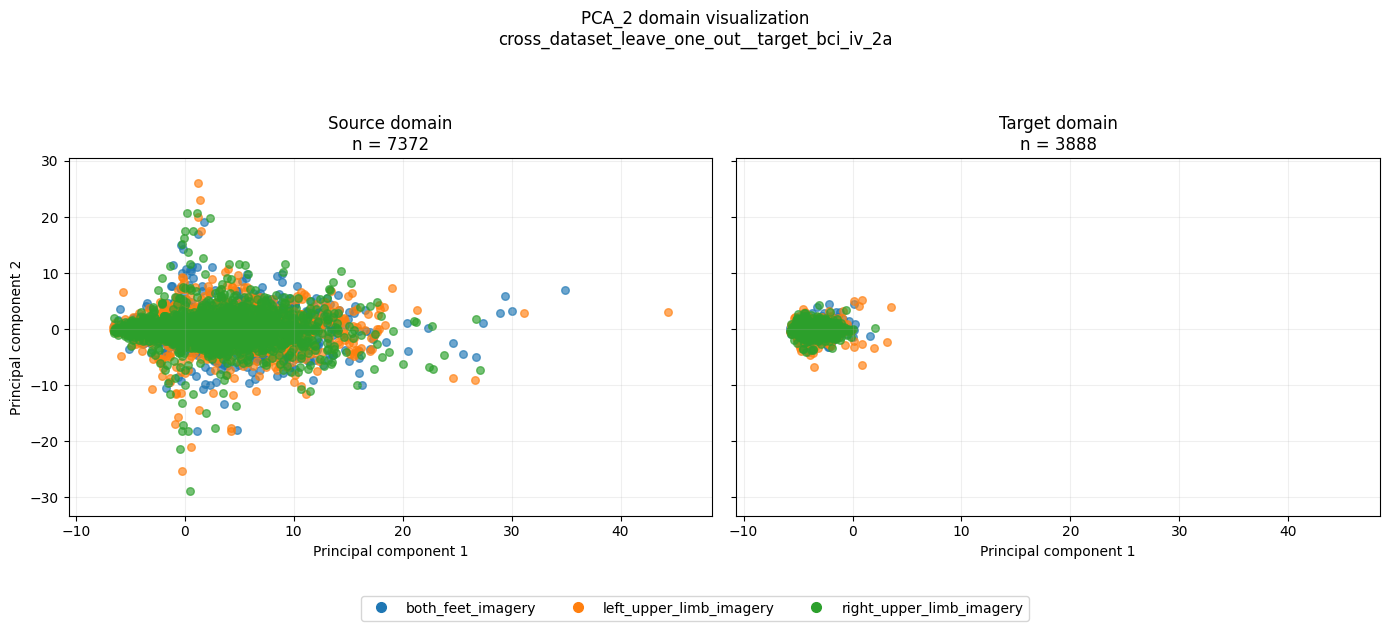

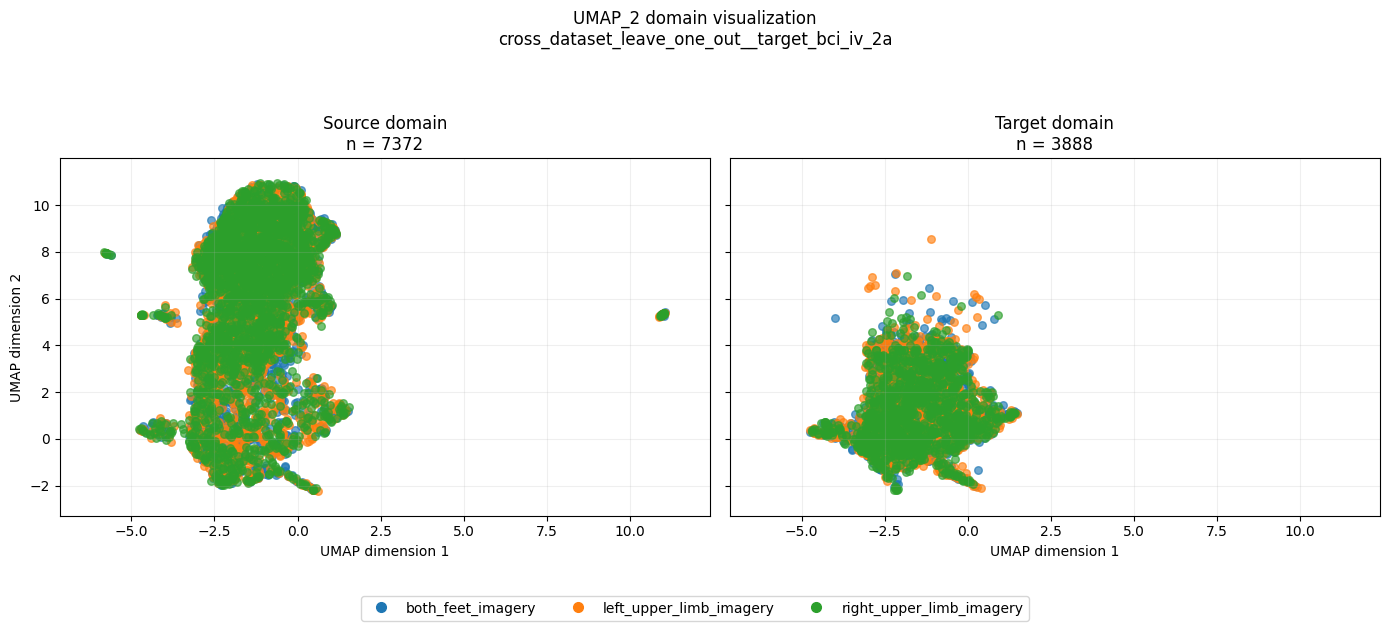

Variance explained by the first two principal components: 40.55%


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.338378,0.338378
1,2,0.067124,0.405502
2,3,0.064813,0.470315
3,4,0.056312,0.526627
4,5,0.048927,0.575554
5,6,0.045790,0.621344
6,7,0.044088,0.665431
7,8,0.033920,0.699351
8,9,0.031683,0.731035
9,10,0.030314,0.761348


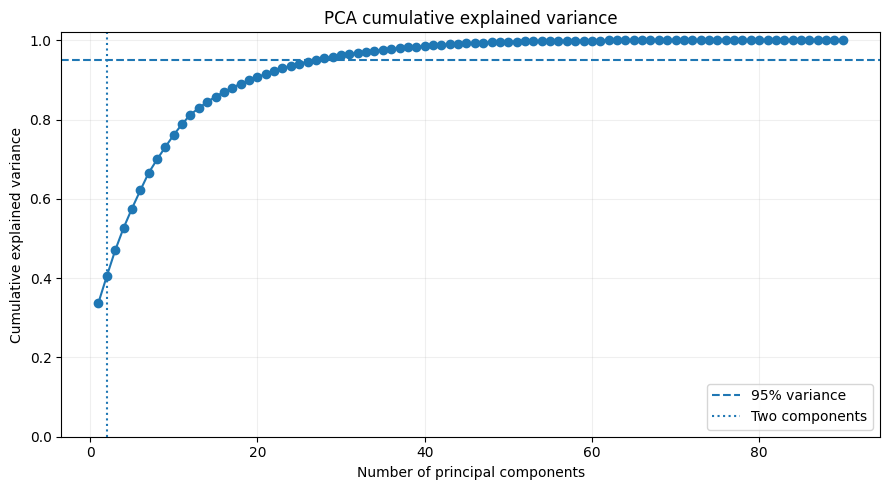

✅ Qualitative domain analysis complete.
Projection data shape: (22520, 17)
Stored projection methods: ['pca_2', 'umap_2']


In [38]:
# ============================================================
# Generate qualitative plots
# ============================================================

AVAILABLE_PROJECTIONS = sorted(
    projection_df[
        "projection_method"
    ]
    .unique()
    .tolist()
)


for projection_method in AVAILABLE_PROJECTIONS:
    plot_source_target_by_label(
        projection_dataframe=projection_df,
        method=projection_method,
        label_color_map=LABEL_COLOR_MAP,
        plot_config=PLOT_CONFIG,
    )


# ============================================================
# PCA explained-variance diagnostics
# ============================================================

if (
    "pca_variance"
    in projection_artifacts["diagnostics"]
):
    pca_variance_df = (
        projection_artifacts[
            "diagnostics"
        ]["pca_variance"]
    )

    pca_2_explained_variance = (
        projection_artifacts[
            "diagnostics"
        ]["pca_2_explained_variance"]
    )

    print(
        "Variance explained by the first two "
        f"principal components: "
        f"{pca_2_explained_variance:.2%}"
    )

    display(
        pca_variance_df.head(20)
    )

    figure, axis = plt.subplots(
        figsize=(9, 5)
    )

    axis.plot(
        pca_variance_df[
            "component"
        ],
        pca_variance_df[
            "cumulative_explained_variance"
        ],
        marker="o",
    )

    axis.axhline(
        y=0.95,
        linestyle="--",
        label="95% variance",
    )

    axis.axvline(
        x=2,
        linestyle=":",
        label="Two components",
    )

    axis.set_title(
        "PCA cumulative explained variance"
    )

    axis.set_xlabel(
        "Number of principal components"
    )

    axis.set_ylabel(
        "Cumulative explained variance"
    )

    axis.set_ylim(
        0,
        1.02,
    )

    axis.grid(alpha=0.2)
    axis.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Store qualitative-analysis outputs
# ============================================================

qualitative_analysis = {
    "split_id": prepared_pair["split_id"],
    "strategy": prepared_pair["strategy"],

    # One row per trial and projection method.
    "projection_data": projection_df,

    # Fitted PCA and UMAP objects and diagnostics.
    "projection_artifacts": (
        projection_artifacts
    ),

    # Reproducibility configurations.
    "projection_config": (
        PROJECTION_CONFIG
    ),
    "plot_config": PLOT_CONFIG,

    # Consistent label-color mapping.
    "label_color_map": (
        LABEL_COLOR_MAP
    ),

    # Features and preprocessing used.
    "feature_realization_id": (
        prepared_pair[
            "feature_realization_id"
        ]
    ),
    "feature_names": prepared_pair[
        "feature_names"
    ],
    "scaler": prepared_pair[
        "scaler"
    ],
}


print(
    "✅ Qualitative domain analysis complete."
)

print(
    "Projection data shape:",
    qualitative_analysis[
        "projection_data"
    ].shape,
)

print(
    "Stored projection methods:",
    sorted(
        qualitative_analysis[
            "projection_data"
        ]["projection_method"]
        .unique()
        .tolist()
    ),
)

In [49]:
# ============================================================
# Stage 3 — Quantitative domain analysis
# Imports and configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance, entropy

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)


QUANTITATIVE_CONFIG = {
    # --------------------------------------------------------
    # Comparisons
    # --------------------------------------------------------

    "analyze_marginal": True,
    "analyze_class_conditional": True,

    # Comparisons with fewer samples are skipped.
    "min_samples_per_domain": 20,

    # Equal numbers of source and target samples are used.
    # None means use every sample from the smaller domain.
    "sampling_mode": "all",  # "all" or "balanced"
    "max_samples_per_domain": None,

    # Initially small for development. Increase later.
    "n_repetitions": 1,

    "seed": 42,

    # --------------------------------------------------------
    # Sample-based distances
    # --------------------------------------------------------

    "sample_distances": [
        "rbf_mmd",
        "energy_distance",
        "sliced_wasserstein",
    ],

    "rbf_mmd": {
        # Median heuristic estimated for each realization.
        "sigma": "median",
    },

    "sliced_wasserstein": {
        "n_projections": 100,
    },

    # --------------------------------------------------------
    # Direct density-ratio estimators
    # --------------------------------------------------------

    "ratio_estimators": [
        "classifier",
        "ulsif",
        "kliep",
    ],

    "ratio_measures": [
        "pearson_divergence",
        "relative_ess",
        "weight_variance",
    ],

    "classifier": {
        "regularization_C": 1.0,
        "n_folds": 5,
        "max_iter": 2000,
        "probability_epsilon": 1e-6,
    },

    "kernel_ratio": {
        # Number of target observations used as kernel centers.
        "n_basis": 100,
        "sigma": "median",
    },

    "ulsif": {
        "regularization": 1e-3,
    },

    "kliep": {
        "learning_rate": 0.1,
        "max_iter": 500,
        "tolerance": 1e-7,
        "epsilon": 1e-10,
    },
}


print("✅ Quantitative-analysis configuration prepared.")

✅ Quantitative-analysis configuration prepared.


In [50]:
# ============================================================
# Sample-based distance functions
# ============================================================

def domain_subsample(
    X_source,
    X_target,
    sampling_mode,
    max_samples_per_domain,
    seed,
):
    """
    Select samples for the quantitative comparison.

    Modes
    -----
    all:
        Use every available source and target sample. The two
        domains may have different sample sizes.

    balanced:
        Randomly select the same number of samples from each
        domain. The number is optionally limited by
        max_samples_per_domain.
    """
    X_source = np.asarray(
        X_source,
        dtype=np.float64,
    )

    X_target = np.asarray(
        X_target,
        dtype=np.float64,
    )

    if len(X_source) == 0 or len(X_target) == 0:
        raise ValueError(
            "Source and target must contain samples."
        )

    # ========================================================
    # Use all available observations
    # ========================================================

    if sampling_mode == "all":
        return (
            X_source,
            X_target,
            np.arange(len(X_source)),
            np.arange(len(X_target)),
        )

    # ========================================================
    # Balanced random subsampling
    # ========================================================

    if sampling_mode == "balanced":
        n_samples = min(
            len(X_source),
            len(X_target),
        )

        if max_samples_per_domain is not None:
            if max_samples_per_domain < 1:
                raise ValueError(
                    "max_samples_per_domain must be "
                    "positive or None."
                )

            n_samples = min(
                n_samples,
                max_samples_per_domain,
            )

        rng = np.random.default_rng(seed)

        source_indices = rng.choice(
            len(X_source),
            size=n_samples,
            replace=False,
        )

        target_indices = rng.choice(
            len(X_target),
            size=n_samples,
            replace=False,
        )

        return (
            X_source[source_indices],
            X_target[target_indices],
            source_indices,
            target_indices,
        )

    raise ValueError(
        f"Unknown sampling mode: {sampling_mode}. "
        "Use 'all' or 'balanced'."
    )


def median_heuristic_sigma(
    X_source,
    X_target,
    seed=42,
    max_points=1000,
):
    """
    Estimate an RBF bandwidth from pooled pairwise distances.
    """
    pooled = np.vstack(
        [
            X_source,
            X_target,
        ]
    )

    if len(pooled) > max_points:
        rng = np.random.default_rng(seed)

        indices = rng.choice(
            len(pooled),
            size=max_points,
            replace=False,
        )

        pooled = pooled[indices]

    squared_distances = pdist(
        pooled,
        metric="sqeuclidean",
    )

    positive_distances = squared_distances[
        squared_distances > 0
    ]

    if len(positive_distances) == 0:
        return 1.0

    sigma = np.sqrt(
        np.median(positive_distances)
    )

    return max(
        float(sigma),
        1e-8,
    )


def rbf_kernel_matrix(
    X,
    Y,
    sigma,
):
    """
    Calculate an RBF-kernel matrix.
    """
    squared_distances = cdist(
        X,
        Y,
        metric="sqeuclidean",
    )

    return np.exp(
        -squared_distances
        / (2.0 * sigma**2)
    )


def calculate_rbf_mmd(
    X_source,
    X_target,
    sigma=None,
    seed=42,
):
    """
    Calculate the nonnegative biased estimate of RBF MMD².
    """
    if sigma is None:
        sigma = median_heuristic_sigma(
            X_source=X_source,
            X_target=X_target,
            seed=seed,
        )

    K_source_source = rbf_kernel_matrix(
        X_source,
        X_source,
        sigma,
    )

    K_target_target = rbf_kernel_matrix(
        X_target,
        X_target,
        sigma,
    )

    K_source_target = rbf_kernel_matrix(
        X_source,
        X_target,
        sigma,
    )

    mmd_squared = (
        K_source_source.mean()
        + K_target_target.mean()
        - 2.0 * K_source_target.mean()
    )

    return max(
        float(mmd_squared),
        0.0,
    ), {
        "sigma": sigma,
    }


def calculate_energy_distance(
    X_source,
    X_target,
):
    """
    Calculate the multivariate energy discrepancy.

    Larger values indicate greater distributional difference.
    """
    source_target_distances = cdist(
        X_source,
        X_target,
        metric="euclidean",
    )

    source_source_distances = cdist(
        X_source,
        X_source,
        metric="euclidean",
    )

    target_target_distances = cdist(
        X_target,
        X_target,
        metric="euclidean",
    )

    value = (
        2.0 * source_target_distances.mean()
        - source_source_distances.mean()
        - target_target_distances.mean()
    )

    return max(
        float(value),
        0.0,
    ), {}


def calculate_sliced_wasserstein(
    X_source,
    X_target,
    n_projections=100,
    seed=42,
):
    """
    Approximate multivariate Wasserstein discrepancy by
    averaging one-dimensional Wasserstein distances over random
    projection directions.
    """
    if X_source.shape[1] != X_target.shape[1]:
        raise ValueError(
            "Source and target must have the same dimension."
        )

    rng = np.random.default_rng(seed)

    directions = rng.normal(
        size=(
            n_projections,
            X_source.shape[1],
        )
    )

    direction_norms = np.linalg.norm(
        directions,
        axis=1,
        keepdims=True,
    )

    directions = directions / np.maximum(
        direction_norms,
        1e-12,
    )

    source_projections = (
        X_source @ directions.T
    )

    target_projections = (
        X_target @ directions.T
    )

    projection_distances = []

    for projection_index in range(
        n_projections
    ):
        value = wasserstein_distance(
            source_projections[
                :,
                projection_index,
            ],
            target_projections[
                :,
                projection_index,
            ],
        )

        projection_distances.append(
            value
        )

    return float(
        np.mean(projection_distances)
    ), {
        "n_projections": n_projections,
    }


def calculate_sample_distances(
    X_source,
    X_target,
    config,
    seed,
):
    """
    Calculate every enabled sample-based distance.
    """
    results = []

    for metric in config["sample_distances"]:
        if metric == "rbf_mmd":
            value, parameters = (
                calculate_rbf_mmd(
                    X_source=X_source,
                    X_target=X_target,
                    sigma=None,
                    seed=seed,
                )
            )

        elif metric == "energy_distance":
            value, parameters = (
                calculate_energy_distance(
                    X_source=X_source,
                    X_target=X_target,
                )
            )

        elif metric == "sliced_wasserstein":
            value, parameters = (
                calculate_sliced_wasserstein(
                    X_source=X_source,
                    X_target=X_target,
                    n_projections=config[
                        "sliced_wasserstein"
                    ]["n_projections"],
                    seed=seed,
                )
            )

        else:
            raise ValueError(
                f"Unknown sample distance: {metric}"
            )

        results.append(
            {
                "metric": metric,
                "value": value,
                "parameters": parameters,
            }
        )

    return results


print("✅ Sample-based distance functions prepared.")

✅ Sample-based distance functions prepared.


In [51]:
# ============================================================
# Direct density-ratio estimation
# ============================================================

def stabilize_density_ratio(
    weights,
    epsilon=1e-10,
):
    """
    Ensure positive finite weights and normalize their source
    mean to one.

    Theoretical importance weights satisfy E_source[w(X)] = 1.
    """
    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    weights = np.nan_to_num(
        weights,
        nan=epsilon,
        posinf=1.0 / epsilon,
        neginf=epsilon,
    )

    weights = np.maximum(
        weights,
        epsilon,
    )

    mean_weight = weights.mean()

    if (
        not np.isfinite(mean_weight)
        or mean_weight <= epsilon
    ):
        return np.ones_like(weights)

    return weights / mean_weight


def estimate_classifier_ratio(
    X_source,
    X_target,
    config,
    seed,
):
    """
    Estimate p_target(x) / p_source(x) through domain
    classification using out-of-fold probabilities.
    """
    X_combined = np.vstack(
        [
            X_source,
            X_target,
        ]
    )

    domain_labels = np.concatenate(
        [
            np.zeros(
                len(X_source),
                dtype=int,
            ),
            np.ones(
                len(X_target),
                dtype=int,
            ),
        ]
    )

    requested_folds = config["n_folds"]

    maximum_folds = min(
        np.bincount(domain_labels)
    )

    n_folds = min(
        requested_folds,
        maximum_folds,
    )

    if n_folds < 2:
        raise ValueError(
            "Classifier ratio estimation requires at "
            "least two samples from each domain."
        )

    cross_validation = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=seed,
    )

    model = LogisticRegression(
        C=config["regularization_C"],
        penalty="l2",
        solver="lbfgs",
        max_iter=config["max_iter"],
        random_state=seed,
    )

    target_probability = cross_val_predict(
        estimator=model,
        X=X_combined,
        y=domain_labels,
        cv=cross_validation,
        method="predict_proba",
    )[:, 1]

    epsilon = config[
        "probability_epsilon"
    ]

    target_probability = np.clip(
        target_probability,
        epsilon,
        1.0 - epsilon,
    )

    source_target_probability = (
        target_probability[
            :len(X_source)
        ]
    )

    # Prior correction:
    #
    # p_t(x) / p_s(x)
    # =
    # P(D=t|x) / P(D=s|x)
    # × P(D=s) / P(D=t)
    prior_correction = (
        len(X_source)
        / len(X_target)
    )

    source_weights = (
        source_target_probability
        / (
            1.0
            - source_target_probability
        )
        * prior_correction
    )

    source_weights = stabilize_density_ratio(
        source_weights
    )

    return source_weights, {
        "n_folds": n_folds,
        "regularization_C": (
            config["regularization_C"]
        ),
    }


def select_kernel_centers(
    X_target,
    n_basis,
    seed,
):
    """
    Select target observations as Gaussian-kernel centers.
    """
    n_basis = min(
        n_basis,
        len(X_target),
    )

    rng = np.random.default_rng(seed)

    indices = rng.choice(
        len(X_target),
        size=n_basis,
        replace=False,
    )

    return X_target[indices]


def create_rbf_basis(
    X,
    centers,
    sigma,
):
    """
    Create Gaussian RBF basis values.
    """
    return rbf_kernel_matrix(
        X=X,
        Y=centers,
        sigma=sigma,
    )


def estimate_ulsif_ratio(
    X_source,
    X_target,
    kernel_config,
    ulsif_config,
    seed,
):
    """
    Estimate density ratios using unconstrained least-squares
    importance fitting.
    """
    sigma = median_heuristic_sigma(
        X_source=X_source,
        X_target=X_target,
        seed=seed,
    )

    centers = select_kernel_centers(
        X_target=X_target,
        n_basis=kernel_config[
            "n_basis"
        ],
        seed=seed,
    )

    basis_source = create_rbf_basis(
        X=X_source,
        centers=centers,
        sigma=sigma,
    )

    basis_target = create_rbf_basis(
        X=X_target,
        centers=centers,
        sigma=sigma,
    )

    H = (
        basis_source.T
        @ basis_source
        / len(X_source)
    )

    h = basis_target.mean(
        axis=0
    )

    regularization = ulsif_config[
        "regularization"
    ]

    regularized_H = (
        H
        + regularization
        * np.eye(H.shape[0])
    )

    try:
        alpha = np.linalg.solve(
            regularized_H,
            h,
        )

    except np.linalg.LinAlgError:
        alpha = np.linalg.pinv(
            regularized_H
        ) @ h

    alpha = np.maximum(
        alpha,
        0.0,
    )

    source_weights = (
        basis_source @ alpha
    )

    source_weights = stabilize_density_ratio(
        source_weights
    )

    return source_weights, {
        "sigma": sigma,
        "n_basis": len(centers),
        "regularization": regularization,
    }


def estimate_kliep_ratio(
    X_source,
    X_target,
    kernel_config,
    kliep_config,
    seed,
):
    """
    Estimate density ratios using a kernel KLIEP objective.

    The optimization maximizes target log-likelihood subject to
    nonnegative ratios with mean source weight equal to one.
    """
    sigma = median_heuristic_sigma(
        X_source=X_source,
        X_target=X_target,
        seed=seed,
    )

    centers = select_kernel_centers(
        X_target=X_target,
        n_basis=kernel_config[
            "n_basis"
        ],
        seed=seed,
    )

    basis_source = create_rbf_basis(
        X=X_source,
        centers=centers,
        sigma=sigma,
    )

    basis_target = create_rbf_basis(
        X=X_target,
        centers=centers,
        sigma=sigma,
    )

    epsilon = kliep_config["epsilon"]

    source_basis_mean = basis_source.mean(
        axis=0
    )

    alpha = np.ones(
        basis_source.shape[1],
        dtype=np.float64,
    )

    normalization = (
        source_basis_mean @ alpha
    )

    alpha = alpha / max(
        normalization,
        epsilon,
    )

    previous_objective = -np.inf

    for iteration in range(
        kliep_config["max_iter"]
    ):
        target_ratio = (
            basis_target @ alpha
        )

        target_ratio = np.maximum(
            target_ratio,
            epsilon,
        )

        gradient = np.mean(
            basis_target
            / target_ratio[:, None],
            axis=0,
        )

        step_size = (
            kliep_config[
                "learning_rate"
            ]
            / np.sqrt(iteration + 1.0)
        )

        alpha = (
            alpha
            + step_size * gradient
        )

        alpha = np.maximum(
            alpha,
            0.0,
        )

        normalization = (
            source_basis_mean @ alpha
        )

        if normalization <= epsilon:
            alpha = np.ones_like(alpha)

            normalization = (
                source_basis_mean @ alpha
            )

        alpha = alpha / max(
            normalization,
            epsilon,
        )

        target_ratio = np.maximum(
            basis_target @ alpha,
            epsilon,
        )

        objective = np.mean(
            np.log(target_ratio)
        )

        if (
            np.isfinite(previous_objective)
            and abs(
                objective
                - previous_objective
            )
            < kliep_config["tolerance"]
        ):
            break

        previous_objective = objective

    source_weights = (
        basis_source @ alpha
    )

    source_weights = stabilize_density_ratio(
        source_weights
    )

    return source_weights, {
        "sigma": sigma,
        "n_basis": len(centers),
        "iterations": iteration + 1,
        "objective": objective,
    }


def estimate_density_ratio(
    estimator,
    X_source,
    X_target,
    config,
    seed,
):
    """
    Run one enabled density-ratio estimator.
    """
    if estimator == "classifier":
        return estimate_classifier_ratio(
            X_source=X_source,
            X_target=X_target,
            config=config["classifier"],
            seed=seed,
        )

    if estimator == "ulsif":
        return estimate_ulsif_ratio(
            X_source=X_source,
            X_target=X_target,
            kernel_config=config[
                "kernel_ratio"
            ],
            ulsif_config=config["ulsif"],
            seed=seed,
        )

    if estimator == "kliep":
        return estimate_kliep_ratio(
            X_source=X_source,
            X_target=X_target,
            kernel_config=config[
                "kernel_ratio"
            ],
            kliep_config=config["kliep"],
            seed=seed,
        )

    raise ValueError(
        f"Unknown ratio estimator: {estimator}"
    )


# ============================================================
# Density-ratio-based measures
# ============================================================

def calculate_ratio_measures(
    source_weights,
):
    """
    Calculate IW-aligned domain-discrepancy diagnostics.
    """
    weights = np.asarray(
        source_weights,
        dtype=np.float64,
    )

    pearson_divergence = (
        0.5
        * np.mean(
            (weights - 1.0) ** 2
        )
    )

    effective_sample_size = (
        weights.sum() ** 2
        / np.sum(weights**2)
    )

    relative_ess = (
        effective_sample_size
        / len(weights)
    )

    weight_variance = np.var(
        weights,
        ddof=0,
    )

    return {
        "pearson_divergence": float(
            pearson_divergence
        ),
        "relative_ess": float(
            relative_ess
        ),
        "weight_variance": float(
            weight_variance
        ),
    }


def summarize_weights(
    weights,
):
    """
    Store additional information about the estimated ratios.
    """
    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    return {
        "weight_mean": float(
            weights.mean()
        ),
        "weight_std": float(
            weights.std(ddof=0)
        ),
        "weight_min": float(
            weights.min()
        ),
        "weight_q05": float(
            np.quantile(weights, 0.05)
        ),
        "weight_q25": float(
            np.quantile(weights, 0.25)
        ),
        "weight_median": float(
            np.quantile(weights, 0.50)
        ),
        "weight_q75": float(
            np.quantile(weights, 0.75)
        ),
        "weight_q95": float(
            np.quantile(weights, 0.95)
        ),
        "weight_max": float(
            weights.max()
        ),
    }


print("✅ Density-ratio functions prepared.")

✅ Density-ratio functions prepared.


In [52]:
# ============================================================
# Construct marginal and class-conditional comparisons
# ============================================================

def construct_quantitative_comparisons(
    prepared_pair,
    config,
):
    """
    Construct:
        1. one marginal source-target comparison;
        2. one comparison for every common class.
    """
    X_source = prepared_pair[
        "X_source"
    ].to_numpy(
        dtype=np.float64
    )

    X_target = prepared_pair[
        "X_target"
    ].to_numpy(
        dtype=np.float64
    )

    y_source = prepared_pair[
        "y_source"
    ].to_numpy()

    y_target = prepared_pair[
        "y_target"
    ].to_numpy()

    comparisons = []

    if config["analyze_marginal"]:
        comparisons.append(
            {
                "comparison_id": "marginal",
                "comparison_type": "marginal",
                "analysis_label": None,
                "X_source": X_source,
                "X_target": X_target,
            }
        )

    if config["analyze_class_conditional"]:
        common_labels = sorted(
            set(y_source)
            & set(y_target)
        )

        for class_label in common_labels:
            source_mask = (
                y_source == class_label
            )

            target_mask = (
                y_target == class_label
            )

            comparisons.append(
                {
                    "comparison_id": (
                        f"class__{class_label}"
                    ),
                    "comparison_type": (
                        "class_conditional"
                    ),
                    "analysis_label": (
                        class_label
                    ),
                    "X_source": (
                        X_source[source_mask]
                    ),
                    "X_target": (
                        X_target[target_mask]
                    ),
                }
            )

    return comparisons


def run_quantitative_domain_analysis(
    prepared_pair,
    config,
):
    """
    Run sample-based and density-ratio-based analyses for every
    comparison and repetition.
    """
    comparisons = (
        construct_quantitative_comparisons(
            prepared_pair=prepared_pair,
            config=config,
        )
    )

    result_records = []
    weight_records = []
    skipped_records = []

    base_seed = config["seed"]

    for comparison_index, comparison in enumerate(
        comparisons
    ):
        X_source_full = comparison[
            "X_source"
        ]

        X_target_full = comparison[
            "X_target"
        ]

        n_source_full = len(
            X_source_full
        )

        n_target_full = len(
            X_target_full
        )

        minimum_samples = config[
            "min_samples_per_domain"
        ]

        if (
            n_source_full < minimum_samples
            or n_target_full < minimum_samples
        ):
            skipped_records.append(
                {
                    "comparison_id": comparison[
                        "comparison_id"
                    ],
                    "comparison_type": comparison[
                        "comparison_type"
                    ],
                    "analysis_label": comparison[
                        "analysis_label"
                    ],
                    "n_source": n_source_full,
                    "n_target": n_target_full,
                    "reason": (
                        "insufficient_samples"
                    ),
                }
            )

            continue

        for repetition in range(
            config["n_repetitions"]
        ):
            repetition_seed = (
                base_seed
                + 10_000 * comparison_index
                + repetition
            )

            (
                X_source,
                X_target,
                source_indices,
                target_indices,
            ) = domain_subsample(
                X_source=X_source_full,
                X_target=X_target_full,
                sampling_mode=config["sampling_mode"],
                max_samples_per_domain=config[
                    "max_samples_per_domain"
                ],
                seed=repetition_seed,
            )

            common_information = {
                "split_id": prepared_pair[
                    "split_id"
                ],
                "strategy": prepared_pair[
                    "strategy"
                ],
                "feature_realization_id": (
                    prepared_pair[
                        "feature_realization_id"
                    ]
                ),
                "n_features": prepared_pair[
                    "n_features"
                ],
                "comparison_id": comparison[
                    "comparison_id"
                ],
                "comparison_type": comparison[
                    "comparison_type"
                ],
                "analysis_label": comparison[
                    "analysis_label"
                ],
                "repetition": repetition,
                "seed": repetition_seed,
                "n_source_full": n_source_full,
                "n_target_full": n_target_full,
                "n_source": len(X_source),
                "n_target": len(X_target),
            }

            # =================================================
            # Sample-based distances
            # =================================================

            sample_results = (
                calculate_sample_distances(
                    X_source=X_source,
                    X_target=X_target,
                    config=config,
                    seed=repetition_seed,
                )
            )

            for sample_result in sample_results:
                result_records.append(
                    {
                        **common_information,
                        "metric_family": (
                            "sample_distance"
                        ),
                        "estimator": None,
                        "metric": sample_result[
                            "metric"
                        ],
                        "value": sample_result[
                            "value"
                        ],
                        "parameters": sample_result[
                            "parameters"
                        ],
                        "status": "ok",
                        "error": None,
                    }
                )

            # =================================================
            # Density-ratio estimators and diagnostics
            # =================================================

            for estimator_index, estimator in enumerate(
                config["ratio_estimators"]
            ):
                estimator_seed = (
                    repetition_seed
                    + 100 * estimator_index
                )

                try:
                    weights, estimator_parameters = (
                        estimate_density_ratio(
                            estimator=estimator,
                            X_source=X_source,
                            X_target=X_target,
                            config=config,
                            seed=estimator_seed,
                        )
                    )

                    ratio_measures = (
                        calculate_ratio_measures(
                            source_weights=weights
                        )
                    )

                    for measure in config[
                        "ratio_measures"
                    ]:
                        result_records.append(
                            {
                                **common_information,
                                "metric_family": (
                                    "ratio_diagnostic"
                                ),
                                "estimator": estimator,
                                "metric": measure,
                                "value": ratio_measures[
                                    measure
                                ],
                                "parameters": (
                                    estimator_parameters
                                ),
                                "status": "ok",
                                "error": None,
                            }
                        )

                    weight_records.append(
                        {
                            **common_information,
                            "estimator": estimator,
                            **summarize_weights(
                                weights
                            ),
                            "parameters": (
                                estimator_parameters
                            ),
                            "status": "ok",
                            "error": None,
                        }
                    )

                except Exception as exception:
                    for measure in config[
                        "ratio_measures"
                    ]:
                        result_records.append(
                            {
                                **common_information,
                                "metric_family": (
                                    "ratio_diagnostic"
                                ),
                                "estimator": estimator,
                                "metric": measure,
                                "value": np.nan,
                                "parameters": {},
                                "status": "failed",
                                "error": str(
                                    exception
                                ),
                            }
                        )

                    weight_records.append(
                        {
                            **common_information,
                            "estimator": estimator,
                            "status": "failed",
                            "error": str(exception),
                        }
                    )

    results_dataframe = pd.DataFrame(
        result_records
    )

    weights_dataframe = pd.DataFrame(
        weight_records
    )

    skipped_dataframe = pd.DataFrame(
        skipped_records
    )

    return {
        "results": results_dataframe,
        "weight_diagnostics": (
            weights_dataframe
        ),
        "skipped_comparisons": (
            skipped_dataframe
        ),
        "configuration": config,
        "comparisons": comparisons,
    }


# ============================================================
# Run quantitative analysis
# ============================================================

quantitative_analysis = (
    run_quantitative_domain_analysis(
        prepared_pair=prepared_pair,
        config=QUANTITATIVE_CONFIG,
    )
)

quantitative_results_df = (
    quantitative_analysis["results"]
)

weight_diagnostics_df = (
    quantitative_analysis[
        "weight_diagnostics"
    ]
)

skipped_comparisons_df = (
    quantitative_analysis[
        "skipped_comparisons"
    ]
)


print("✅ Quantitative domain analysis complete.")

print(
    "Result rows:",
    len(quantitative_results_df),
)

print(
    "Successful rows:",
    (
        quantitative_results_df["status"]
        == "ok"
    ).sum(),
)

print(
    "Failed rows:",
    (
        quantitative_results_df["status"]
        == "failed"
    ).sum(),
)

display(
    quantitative_results_df.head(20)
)

if not skipped_comparisons_df.empty:
    print("\nSkipped comparisons")
    display(skipped_comparisons_df)

✅ Quantitative domain analysis complete.
Result rows: 48
Successful rows: 48
Failed rows: 0


,split_id,strategy,feature_realization_id,n_features,comparison_id,comparison_type,analysis_label,repetition,seed,n_source_full,n_target_full,n_source,n_target,metric_family,estimator,metric,value,parameters,status,error
0,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,sample_distance,None,rbf_mmd,0.205180,{'sigma': 8.983361549746144},ok,None
1,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,sample_distance,None,energy_distance,3.671414,{},ok,None
2,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,sample_distance,None,sliced_wasserstein,0.613489,{'n_projections': 100},ok,None
3,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,classifier,pearson_divergence,179.916781,"{'n_folds': 5, 'regularization_C': 1.0}",ok,None
4,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,classifier,relative_ess,0.002771,"{'n_folds': 5, 'regularization_C': 1.0}",ok,None
5,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,classifier,weight_variance,359.833561,"{'n_folds': 5, 'regularization_C': 1.0}",ok,None
6,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,ulsif,pearson_divergence,0.105153,"{'sigma': 9.054428802078586, 'n_basis': 100, '...",ok,None
7,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,ulsif,relative_ess,0.826237,"{'sigma': 9.054428802078586, 'n_basis': 100, '...",ok,None
8,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,ulsif,weight_variance,0.210306,"{'sigma': 9.054428802078586, 'n_basis': 100, '...",ok,None
9,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,kliep,pearson_divergence,0.101757,"{'sigma': 8.992877098024753, 'n_basis': 100, '...",ok,None


Label proportions


,analysis_label,source_probability,target_probability
0,both_feet_imagery,0.333017,0.333333
1,left_upper_limb_imagery,0.336272,0.333333
2,right_upper_limb_imagery,0.330711,0.333333


Label-distribution discrepancy


,metric,value
0,label_total_variation,0.002939
1,label_jensen_shannon,0.000006


Quantitative summary


,metric_family,estimator,metric,comparison_id,comparison_type,analysis_label,n_repetitions,mean,std,median,q025,q975,minimum,maximum
0,ratio_diagnostic,classifier,pearson_divergence,class__both_feet_imagery,class_conditional,both_feet_imagery,1.0,13.304339,0.0,13.304339,13.304339,13.304339,13.304339,13.304339
1,ratio_diagnostic,classifier,pearson_divergence,class__left_upper_limb_imagery,class_conditional,left_upper_limb_imagery,1.0,93.484289,0.0,93.484289,93.484289,93.484289,93.484289,93.484289
2,ratio_diagnostic,classifier,pearson_divergence,class__right_upper_limb_imagery,class_conditional,right_upper_limb_imagery,1.0,48.900168,0.0,48.900168,48.900168,48.900168,48.900168,48.900168
3,ratio_diagnostic,classifier,pearson_divergence,marginal,marginal,NaN,1.0,179.916781,0.0,179.916781,179.916781,179.916781,179.916781,179.916781
4,ratio_diagnostic,classifier,relative_ess,class__both_feet_imagery,class_conditional,both_feet_imagery,1.0,0.036220,0.0,0.036220,0.036220,0.036220,0.036220,0.036220
5,ratio_diagnostic,classifier,relative_ess,class__left_upper_limb_imagery,class_conditional,left_upper_limb_imagery,1.0,0.005320,0.0,0.005320,0.005320,0.005320,0.005320,0.005320
6,ratio_diagnostic,classifier,relative_ess,class__right_upper_limb_imagery,class_conditional,right_upper_limb_imagery,1.0,0.010121,0.0,0.010121,0.010121,0.010121,0.010121,0.010121
7,ratio_diagnostic,classifier,relative_ess,marginal,marginal,NaN,1.0,0.002771,0.0,0.002771,0.002771,0.002771,0.002771,0.002771
8,ratio_diagnostic,classifier,weight_variance,class__both_feet_imagery,class_conditional,both_feet_imagery,1.0,26.608679,0.0,26.608679,26.608679,26.608679,26.608679,26.608679
9,ratio_diagnostic,classifier,weight_variance,class__left_upper_limb_imagery,class_conditional,left_upper_limb_imagery,1.0,186.968579,0.0,186.968579,186.968579,186.968579,186.968579,186.968579


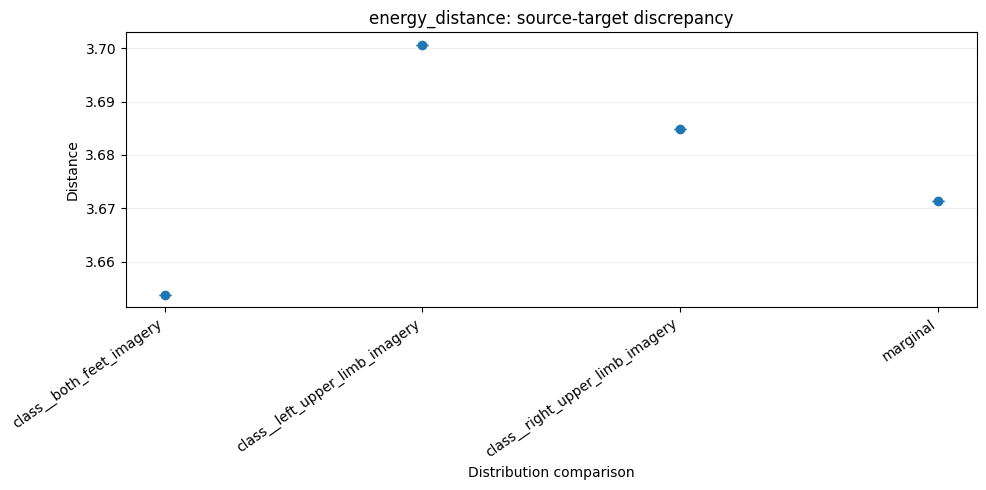

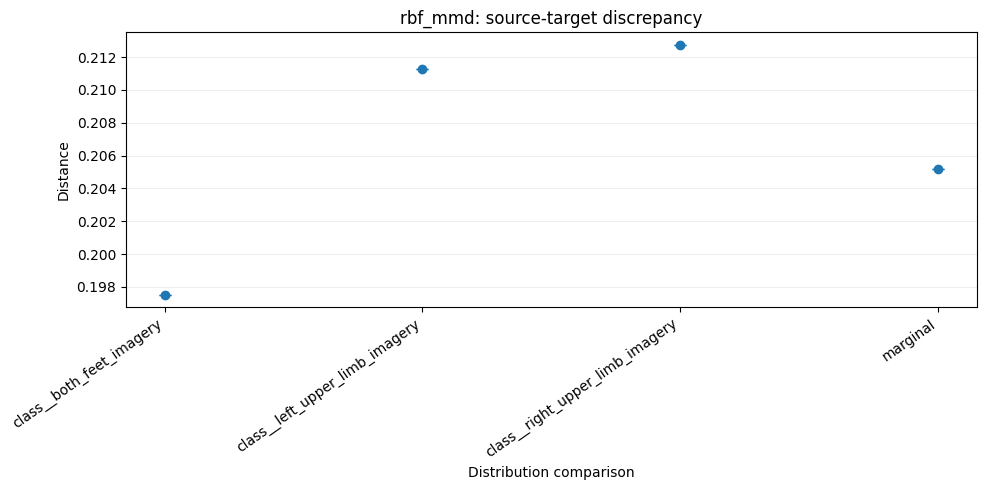

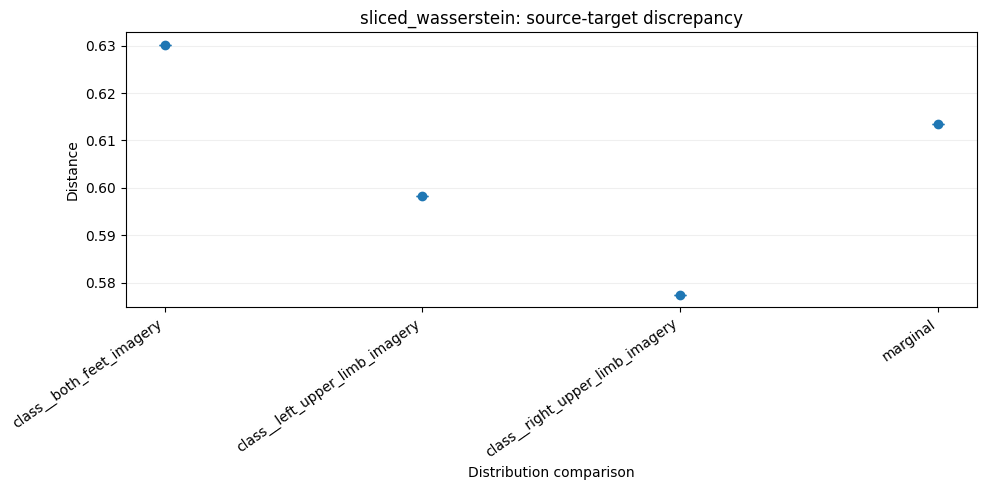

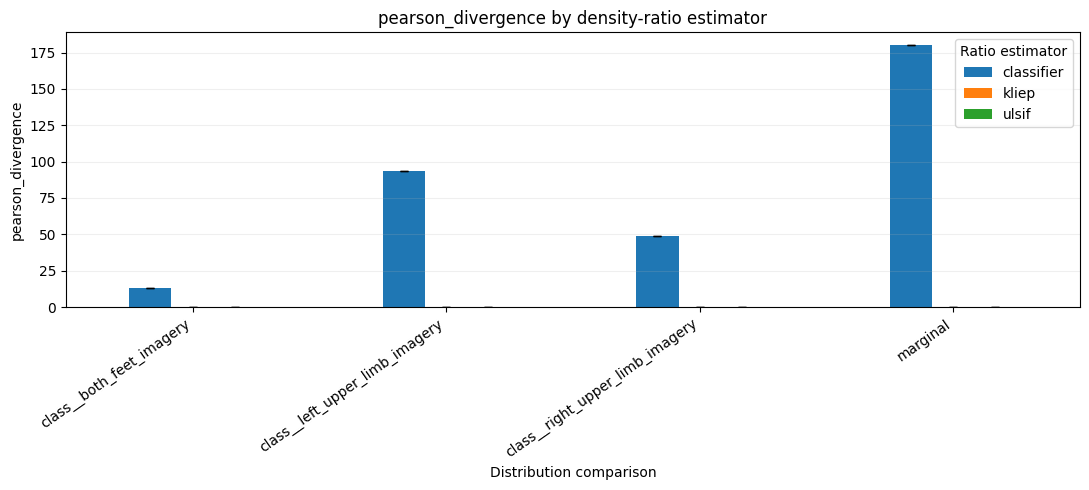

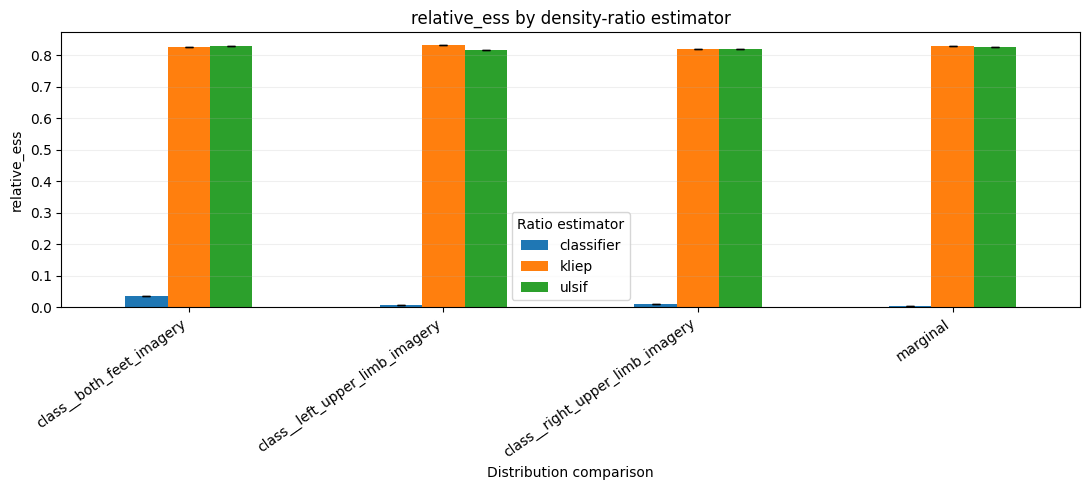

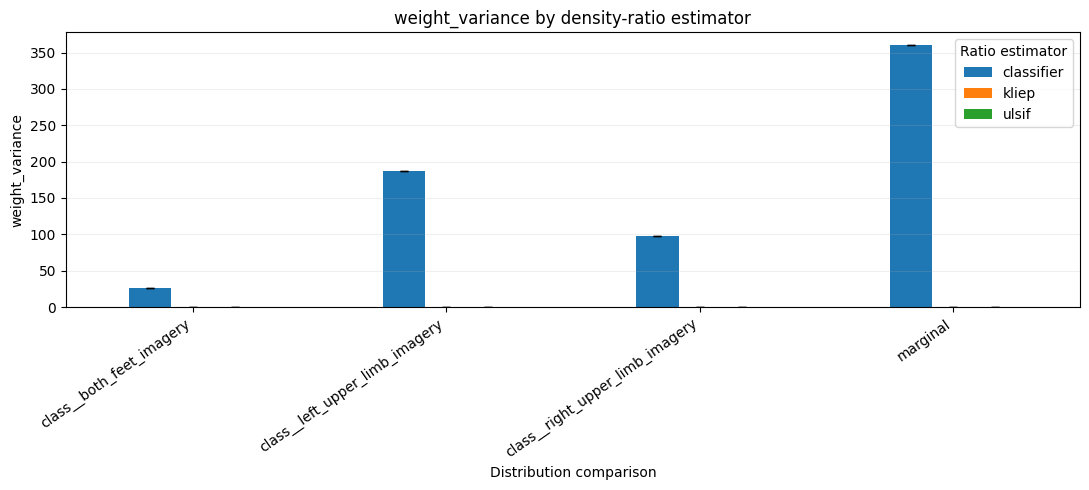

✅ Quantitative summaries and plots created.


In [53]:
# ============================================================
# Compare source and target label distributions
# ============================================================

def calculate_label_shift(
    y_source,
    y_target,
):
    """
    Compare P_source(Y) and P_target(Y).
    """
    labels = sorted(
        set(y_source)
        | set(y_target)
    )

    source_counts = pd.Series(
        y_source
    ).value_counts()

    target_counts = pd.Series(
        y_target
    ).value_counts()

    source_probabilities = np.array(
        [
            source_counts.get(
                label,
                0,
            )
            / len(y_source)
            for label in labels
        ]
    )

    target_probabilities = np.array(
        [
            target_counts.get(
                label,
                0,
            )
            / len(y_target)
            for label in labels
        ]
    )

    distribution_dataframe = pd.DataFrame(
        {
            "analysis_label": labels,
            "source_probability": (
                source_probabilities
            ),
            "target_probability": (
                target_probabilities
            ),
        }
    )

    total_variation = (
        0.5
        * np.abs(
            source_probabilities
            - target_probabilities
        ).sum()
    )

    mixture = (
        0.5
        * (
            source_probabilities
            + target_probabilities
        )
    )

    jensen_shannon = (
        0.5
        * entropy(
            source_probabilities,
            mixture,
        )
        + 0.5
        * entropy(
            target_probabilities,
            mixture,
        )
    )

    metrics_dataframe = pd.DataFrame(
        {
            "metric": [
                "label_total_variation",
                "label_jensen_shannon",
            ],
            "value": [
                total_variation,
                jensen_shannon,
            ],
        }
    )

    return (
        distribution_dataframe,
        metrics_dataframe,
    )


(
    label_distribution_df,
    label_shift_metrics_df,
) = calculate_label_shift(
    y_source=prepared_pair[
        "y_source"
    ],
    y_target=prepared_pair[
        "y_target"
    ],
)


print("Label proportions")
display(label_distribution_df)

print("Label-distribution discrepancy")
display(label_shift_metrics_df)


# ============================================================
# Summarize repeated quantitative results
# ============================================================

successful_results = (
    quantitative_results_df.loc[
        quantitative_results_df[
            "status"
        ] == "ok"
    ]
    .copy()
)


def summarize_metric_group(group):
    values = group[
        "value"
    ].to_numpy()

    return pd.Series(
        {
            "n_repetitions": len(values),
            "mean": np.mean(values),
            "std": (
                np.std(values, ddof=1)
                if len(values) > 1
                else 0.0
            ),
            "median": np.median(values),
            "q025": np.quantile(
                values,
                0.025,
            ),
            "q975": np.quantile(
                values,
                0.975,
            ),
            "minimum": np.min(values),
            "maximum": np.max(values),
        }
    )


quantitative_summary_df = (
    successful_results
    .groupby(
        [
            "metric_family",
            "estimator",
            "metric",
            "comparison_id",
            "comparison_type",
            "analysis_label",
        ],
        dropna=False,
    )
    .apply(
        summarize_metric_group,
        include_groups=False,
    )
    .reset_index()
)


print("Quantitative summary")
display(
    quantitative_summary_df
)


# ============================================================
# Plot sample-based distances
# ============================================================

sample_summary = (
    quantitative_summary_df.loc[
        quantitative_summary_df[
            "metric_family"
        ] == "sample_distance"
    ]
)


for metric in sorted(
    sample_summary["metric"].unique()
):
    plot_dataframe = (
        sample_summary.loc[
            sample_summary["metric"]
            == metric
        ]
        .sort_values(
            "comparison_id"
        )
    )

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    axis.errorbar(
        x=np.arange(
            len(plot_dataframe)
        ),
        y=plot_dataframe["mean"],
        yerr=plot_dataframe["std"],
        marker="o",
        linestyle="",
        capsize=4,
    )

    axis.set_xticks(
        np.arange(
            len(plot_dataframe)
        )
    )

    axis.set_xticklabels(
        plot_dataframe[
            "comparison_id"
        ],
        rotation=35,
        ha="right",
    )

    axis.set_title(
        f"{metric}: source-target discrepancy"
    )

    axis.set_xlabel(
        "Distribution comparison"
    )

    axis.set_ylabel(
        "Distance"
    )

    axis.grid(
        axis="y",
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Plot density-ratio diagnostics
# ============================================================

ratio_summary = (
    quantitative_summary_df.loc[
        quantitative_summary_df[
            "metric_family"
        ] == "ratio_diagnostic"
    ]
)


for metric in sorted(
    ratio_summary["metric"].unique()
):
    metric_dataframe = (
        ratio_summary.loc[
            ratio_summary["metric"]
            == metric
        ]
    )

    mean_table = metric_dataframe.pivot(
        index="comparison_id",
        columns="estimator",
        values="mean",
    )

    std_table = metric_dataframe.pivot(
        index="comparison_id",
        columns="estimator",
        values="std",
    )

    axis = mean_table.plot(
        kind="bar",
        yerr=std_table,
        capsize=3,
        figsize=(11, 5),
    )

    axis.set_title(
        f"{metric} by density-ratio estimator"
    )

    axis.set_xlabel(
        "Distribution comparison"
    )

    axis.set_ylabel(
        metric
    )

    axis.grid(
        axis="y",
        alpha=0.2,
    )

    axis.legend(
        title="Ratio estimator"
    )

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Add final outputs to the stored analysis object
# ============================================================

quantitative_analysis[
    "summary"
] = quantitative_summary_df

quantitative_analysis[
    "label_distribution"
] = label_distribution_df

quantitative_analysis[
    "label_shift_metrics"
] = label_shift_metrics_df


print("✅ Quantitative summaries and plots created.")

The idea we have so far is a good mapping, but it is still kind of hard to organize, lets continue with the idea bellow and organize it a little better and also define the methods used ok, and the overall idea of domain analysis:

- Guess we should devide into a few subgroups
- one groups go untill perhaps we stanrdardize the data so it envolves some formatting and feature definitions that will be used
- other group envolves the representation of the data in a lower dimension right, for this I think we use only the input data right, and I think all visualization estimation of density and distances goes in this reduced space right? Or do you think that estimations and such should go on the higher dimensional space?
- other group is to estimate densities, this will be does marginal or input or conditional distributions right.
- other group calculates distances and such.
- other group defines the data necessary to be captured and stored
- other group is about the important plots or tables that can be generater
- other groups is about multiple experimentations, it manages the many realizations of the pipeline, guess here is not about seeds, it is more about the several different combinations right? perhaps just a for loop is enough, or perhaps need seeds, depends on the feature realization, because it could be random seections or it could be more predefined, understand?

So what do you think. this part we have a lot of things to think about and i am not sure hhow to start or organize it all. Perhaps we should better structure it all and beging the code starting from the domains we have previously constructed

select one split
→ harmonize source and target
→ create feature realizations
→ standardize
→ create representations
→ visualize distributions
→ calculate distances
→ repeat/bootstrap
→ store and summarize results

marginal
label distribution
class-conditional

2. Harmonize and filter the data

This prepares the selected source and target pair:

map dataset-specific labels to a common analysis label;
select which common labels participate;
keep the original label in a separate column;
choose compatible feature columns;
handle unavailable features;
remove invalid or constant features;
optionally balance source and target sample sizes;
standardize using source-fitted parameters.

Representations
original standardized feature space;
PCA with fixed dimensions;
PCA retaining a percentage of variance;
random feature subsets;
predefined feature families or frequency bands.

For visualization:

PCA;
UMAP later;
possibly t-SNE only as an exploratory plot.
Sample-based distances

These should be the main quantitative methods:

MMD with different kernels;
energy distance;
sliced Wasserstein distance;
domain-classifier accuracy or proxy A-distance.
Density-based methods

Use mainly in low-dimensional spaces:

KDE;
Gaussian model;
Gaussian mixture model.

Then compare densities using:

Jensen–Shannon divergence;
Hellinger distance;
possibly KL divergence, although it is less stable.
Stability

Repeat calculations using:

bootstrap samples;
balanced source–target subsamples;
multiple random feature realizations;
multiple random seeds.